#ASAP Summer School
Thursday 11/6/2026

##Hands on session on solar structure segmentation and solar flare forecasting

2. Solar Flare Forecasting (SHARP)

In this part you will work with the SHARP (Space-weather HMI Active Region Patches) dataset. SHARP parameters are magnetic field descriptors extracted from solar active regions. Your goal is to explore, cluster, and ultimately forecast solar flare events from these parameters.

You can find the description of the SHARP parameters here: [JSOC SHARP](http://jsoc.stanford.edu/doc/data/hmi/sharp/old/sharp.MB.htm). You can check the general meaning of each parameters quickly from this page.

Link to the data for this hands-on exercise: [gitlab link](https://gitlab.com/georgemilosh/clustering_ar_sf_hbaeke/-/blob/main/Data/AllData_sharp.csv?ref_type=heads). For a context you might want to check [this article](https://academic.oup.com/mnras/article/546/1/staf2271/8404166?guestAccessKey=).

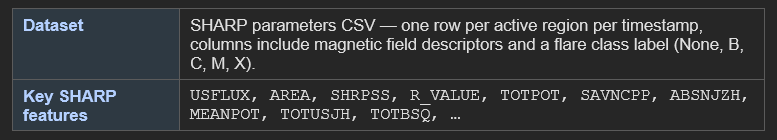

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p data

!wget -O data/AllData_sharp.csv \
"https://gitlab.com/georgemilosh/clustering_ar_sf_hbaeke/-/raw/main/Data/AllData_sharp.csv?ref_type=heads&inline=false"

--2026-06-10 15:45:40--  https://gitlab.com/georgemilosh/clustering_ar_sf_hbaeke/-/raw/main/Data/AllData_sharp.csv?ref_type=heads&inline=false
Resolving gitlab.com (gitlab.com)... 172.65.251.78, 2606:4700:90:0:f22e:fbec:5bed:a9b9
Connecting to gitlab.com (gitlab.com)|172.65.251.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1921673425 (1.8G) [application/octet-stream]
Saving to: ‘data/AllData_sharp.csv’

data/AllData_sharp. 100%[===================>]   1.79G  97.6MB/s    in 15s     

2026-06-10 15:45:56 (122 MB/s) - ‘data/AllData_sharp.csv’ saved [1921673425/1921673425]



In [4]:
# Core libraries used throughout the notebook
import gc
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"])
    from imblearn.over_sampling import SMOTE

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mannwhitneyu, pointbiserialr
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    silhouette_score,
 )
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def optimize_dataframe_memory(df):
    optimized = df.copy()
    for column in optimized.select_dtypes(include=["int64", "int32"]).columns:
        optimized[column] = pd.to_numeric(optimized[column], downcast="integer")
    for column in optimized.select_dtypes(include=["float64", "float32"]).columns:
        optimized[column] = pd.to_numeric(optimized[column], downcast="float")

    category_candidates = [
        column
        for column in ["SPEI", "IS_TMFI", "flare_class", "USFLUX_bin"]
        if column in optimized.columns
    ]
    for column in category_candidates:
        optimized[column] = optimized[column].astype("category")

    return optimized

def dataframe_memory_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

def stratified_sample(df, group_col, max_total_rows=120000, min_per_group=1000, random_state=42):
    if len(df) <= max_total_rows:
        return df

    sampled_parts = []
    group_sizes = df[group_col].value_counts(dropna=False)
    sampling_fraction = max_total_rows / len(df)

    for group_value, group_size in group_sizes.items():
        group = df[df[group_col] == group_value]
        target_size = max(min_per_group, int(np.ceil(group_size * sampling_fraction)))
        target_size = min(len(group), target_size)
        sampled_parts.append(group.sample(n=target_size, random_state=random_state))

    sampled_df = pd.concat(sampled_parts).sort_index()
    if len(sampled_df) > max_total_rows:
        sampled_df = sampled_df.sample(n=max_total_rows, random_state=random_state).sort_index()

    return sampled_df

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

### Loading and First Look
1.	Load the dataset with pd.read_csv(). Display the first 10 rows.
2.	Run df.info() and df.describe(). Take stock of the data: How many observations and features are there? Are there missing values? Which columns, and what percentage?
3.	What are the unique flare class values? Plot the class distribution as a bar chart.
4.	What is the ratio between classes? This is real life data. What challenges does this pose for classification?


In [5]:
data_path = os.path.join("data", "AllData_sharp.csv")

# 1. Load dataset
df_SHARP = pd.read_csv(data_path, sep="\t", low_memory=False)
raw_memory_mb = dataframe_memory_mb(df_SHARP)
df_SHARP = optimize_dataframe_memory(df_SHARP)
optimized_memory_mb = dataframe_memory_mb(df_SHARP)

print(f"Loaded SHARP dataset from: {data_path}")
print(f"Dataset shape: {df_SHARP.shape}")
print(f"Memory usage: {raw_memory_mb:.2f} MB -> {optimized_memory_mb:.2f} MB after downcasting")

# Display first 10 rows
print(df_SHARP.head(10))

Loaded SHARP dataset from: data/AllData_sharp.csv
Dataset shape: (2879658, 57)
Memory usage: 1908.74 MB -> 1499.55 MB after downcasting
   Unnamed: 0            Timestamp   TOTUSJH        TOTBSQ        TOTPOT  \
0           0  2012-01-05 14:36:00  3.661010  1.717761e+07  1.422759e+20   
1           1  2012-01-05 14:48:00  2.426799  1.648750e+07  1.175725e+20   
2           2  2012-01-05 15:00:00       NaN           NaN           NaN   
3           3  2012-01-05 15:12:00       NaN           NaN           NaN   
4           4  2012-01-05 15:24:00       NaN           NaN           NaN   
5           5  2012-01-05 15:36:00       NaN           NaN           NaN   
6           6  2012-01-05 15:48:00       NaN           NaN           NaN   
7           7  2012-01-05 16:00:00       NaN           NaN           NaN   
8           8  2012-01-05 16:12:00       NaN           NaN           NaN   
9           9  2012-01-05 16:24:00       NaN           NaN           NaN   

        TOTUSJZ   ABSNJZH  

In [6]:
# 2. Inspect missing values without dropping the flare-label columns needed later
missing_fraction = df_SHARP.isna().mean().sort_values(ascending=False)
missing_summary = (
    missing_fraction[missing_fraction > 0]
    .mul(100)
    .round(2)
    .rename("missing_percent")
    .to_frame()
 )

print("Columns with missing values (% of rows):")
print(missing_summary)

# Keep the main SHARP parameters and flare flags available for later steps.
# Only remove columns that are entirely missing.
all_nan_columns = missing_fraction[missing_fraction == 1.0].index.tolist()
df_clean = df_SHARP.drop(columns=all_nan_columns, errors="ignore")

print("\nColumns removed because they are completely empty:")
print(all_nan_columns if all_nan_columns else "None")
print(f"Remaining number of columns: {df_clean.shape[1]}")

# 3. Build a single flare class column using the highest available flare flag
flare_priority = ["XFLARE", "MFLARE", "CFLARE", "BFLARE"]
flare_label_map = {
    "XFLARE": "X",
    "MFLARE": "M",
    "CFLARE": "C",
    "BFLARE": "B",
}

df_clean["flare_class"] = "No flare"
for flare_col in flare_priority:
    if flare_col in df_clean.columns:
        flare_values = pd.to_numeric(df_clean[flare_col], errors="coerce").fillna(0)
        df_clean.loc[flare_values > 0, "flare_class"] = flare_label_map[flare_col]

df_clean = optimize_dataframe_memory(df_clean)

# 4. Basic dataset information after cleaning
print("\nDataset info after removing fully empty columns:")
df_clean.info()

print("\nSummary statistics for numeric columns:")
print(df_clean.describe().T)

n_observations, n_features = df_clean.shape
print(f"\nNumber of observations: {n_observations}")
print(f"Number of features/columns: {n_features}")
print(f"Working memory after cleaning: {dataframe_memory_mb(df_clean):.2f} MB")

# 5. Flare class inspection
print("\nUnique flare class values:")
print(df_clean["flare_class"].unique())

class_counts = df_clean["flare_class"].value_counts()
class_percent = 100 * class_counts / len(df_clean)

class_summary = pd.DataFrame({
    "count": class_counts,
    "percent": class_percent
})

print("\nClass distribution:")
print(class_summary)

Columns with missing values (% of rows):
                  missing_percent
XFLARE_LABEL_LOC           100.00
XFLARE_LABEL               100.00
MFLARE_LABEL_LOC            99.98
MFLARE_LABEL                99.98
BFLARE_LABEL                99.84
BFLARE_LABEL_LOC            99.83
CFLARE_LABEL_LOC            99.76
CFLARE_LABEL                99.76
MEANPOT                      9.34
MEANSHR                      9.34
MEANGBT                      9.34
MEANALP                      9.34
MEANJZH                      9.34
MEANGBZ                      9.34
MEANGBH                      9.34
MEANJZD                      9.34
EPSX                         9.34
EPSZ                         9.34
EPSY                         9.34
MEANGAM                      9.34
SHRGT45                      9.31
LON_MIN                      8.88
LAT_MIN                      8.88
LON_MAX                      8.88
LAT_MAX                      8.88
TOTPOT                       8.16
ABSNJZH                      8.16
TOTUSJZ

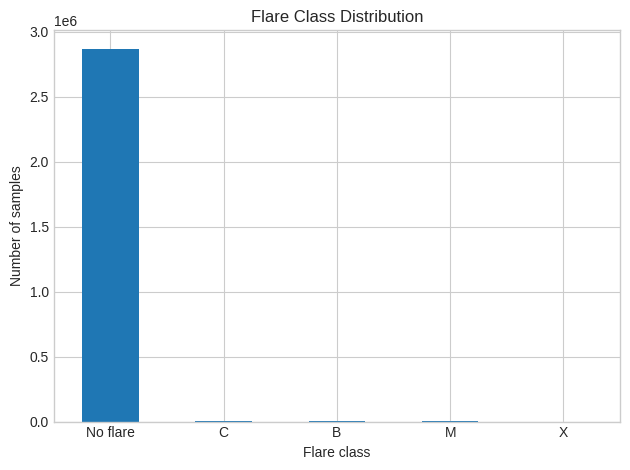


Class ratios relative to the smallest class:
flare_class
No flare    61004.574468
C             149.851064
B              98.978723
M              14.914894
X               1.000000
Name: count, dtype: float64


In [7]:
# 5. Plot class distribution
class_counts.plot(kind="bar")

plt.xlabel("Flare class")
plt.ylabel("Number of samples")
plt.title("Flare Class Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Ratio between classes
# -----------------------------
print("\nClass ratios relative to the smallest class:")
minority_count = class_counts.min()
class_ratio = class_counts / minority_count

print(class_ratio)

### Cleaning & Preprocessing
5.	For remaining missing values, impute with the column median.
6.	Use a low-flux threshold to exclude very low USFLUX values, thus, reducing the number of non-flaring regions which are anyways too many.
7.	Check for and remove duplicate rows.
8.	Convert the timestamp column to datetime and set it as the index.
9.	(Bonus) Plot the number of active region observations over time as a time series.


In [8]:
# 5-8. Cleaning and preprocessing example
label_text_columns = [
    "BFLARE_LABEL",
    "CFLARE_LABEL",
    "MFLARE_LABEL",
    "XFLARE_LABEL",
    "BFLARE_LABEL_LOC",
    "CFLARE_LABEL_LOC",
    "MFLARE_LABEL_LOC",
    "XFLARE_LABEL_LOC",
]
flare_flag_columns = ["BFLARE", "CFLARE", "MFLARE", "XFLARE", "BFLARE_LOC", "CFLARE_LOC", "MFLARE_LOC", "XFLARE_LOC"]

df_preprocessed = df_clean.drop(columns=label_text_columns, errors="ignore").copy()
for column in flare_flag_columns:
    if column in df_preprocessed.columns:
        df_preprocessed[column] = pd.to_numeric(df_preprocessed[column], errors="coerce").fillna(0)

# Build one flare label per row, keeping the highest-severity class
flare_conditions = [
    df_preprocessed["XFLARE"] > 0,
    df_preprocessed["MFLARE"] > 0,
    df_preprocessed["CFLARE"] > 0,
    df_preprocessed["BFLARE"] > 0,
]
flare_choices = ["X", "M", "C", "B"]
df_preprocessed["flare_class"] = np.select(flare_conditions, flare_choices, default="No flare")

# Impute remaining missing numeric values with the column median
numeric_cols = df_preprocessed.select_dtypes(include="number").columns
numeric_medians = df_preprocessed[numeric_cols].median()
df_preprocessed.loc[:, numeric_cols] = df_preprocessed[numeric_cols].fillna(numeric_medians)

# Use a low-flux threshold to reduce the number of weak non-flaring regions
usflux_threshold = df_preprocessed["USFLUX"].quantile(0.10)
df_preprocessed = df_preprocessed.loc[df_preprocessed["USFLUX"] > usflux_threshold]
print(f"USFLUX threshold used: {usflux_threshold:.3e}")
print(f"Rows after USFLUX filtering: {len(df_preprocessed)}")

# Check for and remove duplicate rows
n_duplicates = df_preprocessed.duplicated().sum()
df_preprocessed = df_preprocessed.drop_duplicates()
print(f"Duplicate rows removed: {n_duplicates}")

# Convert timestamp to datetime and set it as the index
df_preprocessed["Timestamp"] = pd.to_datetime(df_preprocessed["Timestamp"], errors="coerce")
df_preprocessed = df_preprocessed.dropna(subset=["Timestamp"]).sort_values("Timestamp").set_index("Timestamp")
df_preprocessed = optimize_dataframe_memory(df_preprocessed)

print("\nPreprocessed dataset info:")
df_preprocessed.info()
print(f"Preprocessed memory usage: {dataframe_memory_mb(df_preprocessed):.2f} MB")

print("\nFirst rows after preprocessing:")
print(df_preprocessed.head())

del numeric_medians
gc.collect()

USFLUX threshold used: 1.629e+20
Rows after USFLUX filtering: 2591692
Duplicate rows removed: 0

Preprocessed dataset info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2591692 entries, 2010-05-01 00:00:00 to 2019-01-07 02:00:00
Data columns (total 49 columns):
 #   Column       Dtype   
---  ------       -----   
 0   Unnamed: 0   int32   
 1   TOTUSJH      float64 
 2   TOTBSQ       float64 
 3   TOTPOT       float64 
 4   TOTUSJZ      float64 
 5   ABSNJZH      float32 
 6   SAVNCPP      float64 
 7   USFLUX       float64 
 8   TOTFZ        float64 
 9   MEANPOT      float64 
 10  EPSZ         float32 
 11  MEANSHR      float32 
 12  SHRGT45      float32 
 13  MEANGAM      float32 
 14  MEANGBT      float32 
 15  MEANGBZ      float32 
 16  MEANGBH      float32 
 17  MEANJZH      float32 
 18  TOTFY        float64 
 19  MEANJZD      float32 
 20  MEANALP      float32 
 21  TOTFX        float64 
 22  EPSY         float32 
 23  EPSX         float32 
 24  R_VALUE      float32 
 

3109

### Pandas Feature Tests
10. Visualize your data: plot time series, identify active regions according to HARP number.
11. Use groupby to compute the mean and std of each SHARP parameter per flare class. Which features differ most between classes?
12.	Use .pivot_table() to show mean USFLUX per flare class and per year.
13.	Using boolean indexing, extract only M-class and X-class flares. How many are there?
14.	Create a new binary column flare_binary: 0 = no flare (B/C/None), 1 = flare (M/X).
15.	Use pd.cut() to bin USFLUX into 5 quantile bins. What is the flare rate in each bin?


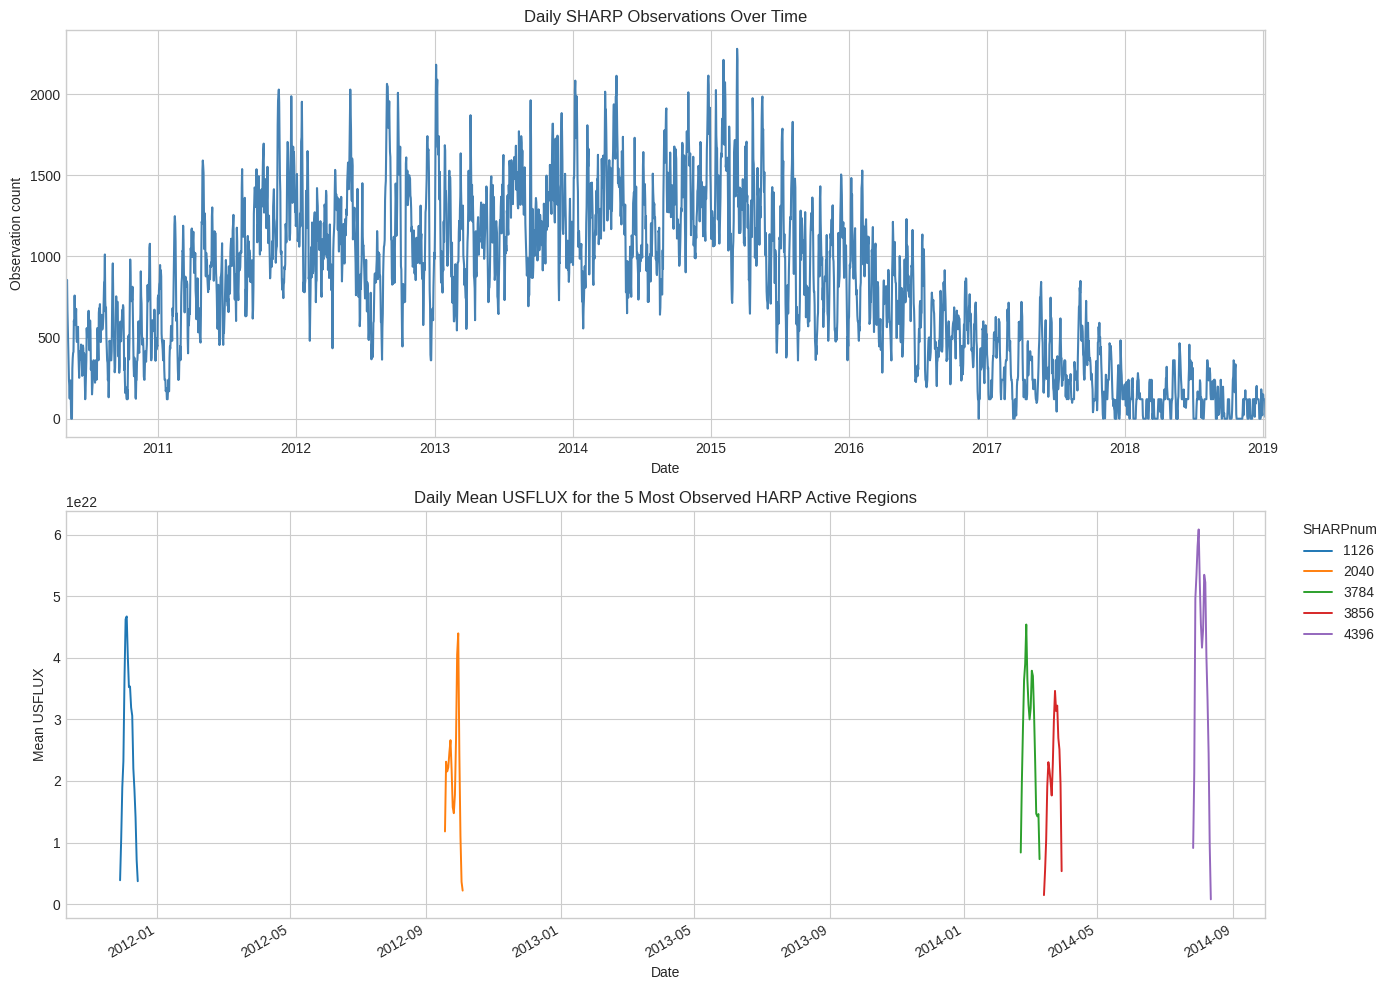

Top active regions by SHARP number:
          observations  mx_flares   mean_usflux
SHARPnum                                       
4698              1716         39  1.305033e+23
1807              1665         31  4.080978e+22
7115              1525         30  2.233106e+22
3686              1712         23  7.021715e+22
5298              1679         22  2.439963e+22
892               1719         17  3.570458e+22
1449              1575         17  4.325341e+22
5983              1358         17  3.439409e+22
3721              1685         14  3.412013e+22
3291              1591         14  3.332750e+22

Mean and std of SHARP parameters by flare class:
               Unnamed: 0                     TOTUSJH               \
                     mean            std         mean          std   
flare_class                                                          
B            1.509162e+06  951868.057532  1047.002591   846.730389   
C            1.417274e+06  766657.963401  2271.134052  192

/tmp/ipykernel_36744/1712865946.py:72: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  usflux_pivot = pd.pivot_table(



Flare rate by USFLUX quantile bin:
                                                  flare_rate   n_obs
USFLUX_bin                                                          
(1.6288400970106e+20, 5.8833710633673785e+20]       0.000006  518339
(5.8833710633673785e+20, 1.8268878435399395e+21]    0.000040  751066
(1.8268878435399395e+21, 3.512501806408159e+21]     0.000025  285610
(3.512501806408159e+21, 1.0312194341674896e+22]     0.000062  518338
(1.0312194341674896e+22, 2.077737061737166e+23]     0.001293  518339


0

In [ ]:
# 10-15. SHARP feature exploration by flare class
analysis_df = df_preprocessed.sort_index()

# Restore year information from the datetime index without copying the full table.
analysis_year = pd.Series(analysis_df.index.year, index=analysis_df.index, name="year", dtype="int16")

# 10. Visualize the time series and identify active regions by HARP number.
observations_over_time = analysis_df.resample("D").size()
top_harp = analysis_df["SHARPnum"].value_counts().head(5).index
harp_time_series = (
    analysis_df.loc[analysis_df["SHARPnum"].isin(top_harp)]
    .groupby([pd.Grouper(freq="D"), "SHARPnum"])["USFLUX"]
    .mean()
    .unstack()
 )

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
observations_over_time.plot(ax=axes[0], color="steelblue", linewidth=1.5)
axes[0].set_title("Daily SHARP Observations Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Observation count")

harp_time_series.plot(ax=axes[1], linewidth=1.4)
axes[1].set_title("Daily Mean USFLUX for the 5 Most Observed HARP Active Regions")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Mean USFLUX")
axes[1].legend(title="SHARPnum", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

active_region_summary = (
    analysis_df.groupby("SHARPnum")
    .agg(
        observations=("SHARPnum", "size"),
        mx_flares=("flare_class", lambda values: values.isin(["M", "X"]).sum()),
        mean_usflux=("USFLUX", "mean"),
    )
    .sort_values(["mx_flares", "observations", "mean_usflux"], ascending=False)
 )
print("Top active regions by SHARP number:")
print(active_region_summary.head(10))

# 11. Mean/std of SHARP parameters per flare class and the features with the largest class separation.
exclude_cols = {
    "HARPNUM",
    "BFLARE",
    "CFLARE",
    "MFLARE",
    "XFLARE",
    "flare_binary",
}
sharp_parameters = [
    column
    for column in analysis_df.select_dtypes(include="number").columns
    if column not in exclude_cols
 ]

sharp_group_stats = analysis_df.groupby("flare_class", observed=False)[sharp_parameters].agg(["mean", "std"])
print("\nMean and std of SHARP parameters by flare class:")
print(sharp_group_stats)

feature_mean_spread = (
    analysis_df.groupby("flare_class", observed=False)[sharp_parameters]
    .mean()
    .agg(lambda column: column.max() - column.min())
    .sort_values(ascending=False)
 )
print("\nFeatures with the largest difference in class means:")
print(feature_mean_spread.head(10))

# 12. Pivot table of mean USFLUX by flare class and year.
usflux_pivot = pd.pivot_table(
    pd.DataFrame({
        "year": analysis_year,
        "flare_class": analysis_df["flare_class"],
        "USFLUX": analysis_df["USFLUX"],
    }),
    values="USFLUX",
    index="year",
    columns="flare_class",
    aggfunc="mean",
 )
print("\nMean USFLUX by flare class and year:")
print(usflux_pivot)

# 13. Boolean indexing for M- and X-class flares.
mx_flares = analysis_df.loc[analysis_df["flare_class"].isin(["M", "X"]), ["SHARPnum", "USFLUX", "flare_class"]]
print(f"\nNumber of M-class and X-class flares: {len(mx_flares)}")
print(mx_flares.head())

# 14. Binary flare target: 0 for B/C/No flare, 1 for M/X.
df_preprocessed["flare_binary"] = analysis_df["flare_class"].isin(["M", "X"]).astype("int8")
print("\nflare_binary value counts:")
print(df_preprocessed["flare_binary"].value_counts().sort_index())

# 15. Quantile-based USFLUX bins using pd.cut().
quantile_edges = analysis_df["USFLUX"].quantile(np.linspace(0, 1, 6)).to_numpy()
quantile_edges = np.unique(quantile_edges)
df_preprocessed["USFLUX_bin"] = pd.cut(
    analysis_df["USFLUX"],
    bins=quantile_edges,
    include_lowest=True,
    duplicates="drop",
)
df_preprocessed = optimize_dataframe_memory(df_preprocessed)

flare_rate_by_bin = df_preprocessed.groupby("USFLUX_bin", observed=False)["flare_binary"].agg(["mean", "count"])
flare_rate_by_bin = flare_rate_by_bin.rename(columns={"mean": "flare_rate", "count": "n_obs"})
print("\nFlare rate by USFLUX quantile bin:")
print(flare_rate_by_bin)

del analysis_year
gc.collect()

### Correleation Analysis
15.	Compute the Spearman ρ correlation matrix for all SHARP features using df.corr().
16.	Visualise it as a heatmap with seaborn.heatmap(). Use a diverging colormap (coolwarm).
17.	Identify the most vs least correlated feature pairs. What might explain these correlations physically?
18.	Compute the point-biserial correlation between each SHARP feature and flare_binary. Which features are most predictive of flaring?
19.	Plot a scatter matrix (pd.plotting.scatter_matrix) for the top 5 predictive features, coloured by flare class.


Correlation analysis uses a stratified sample of 120,000 rows.


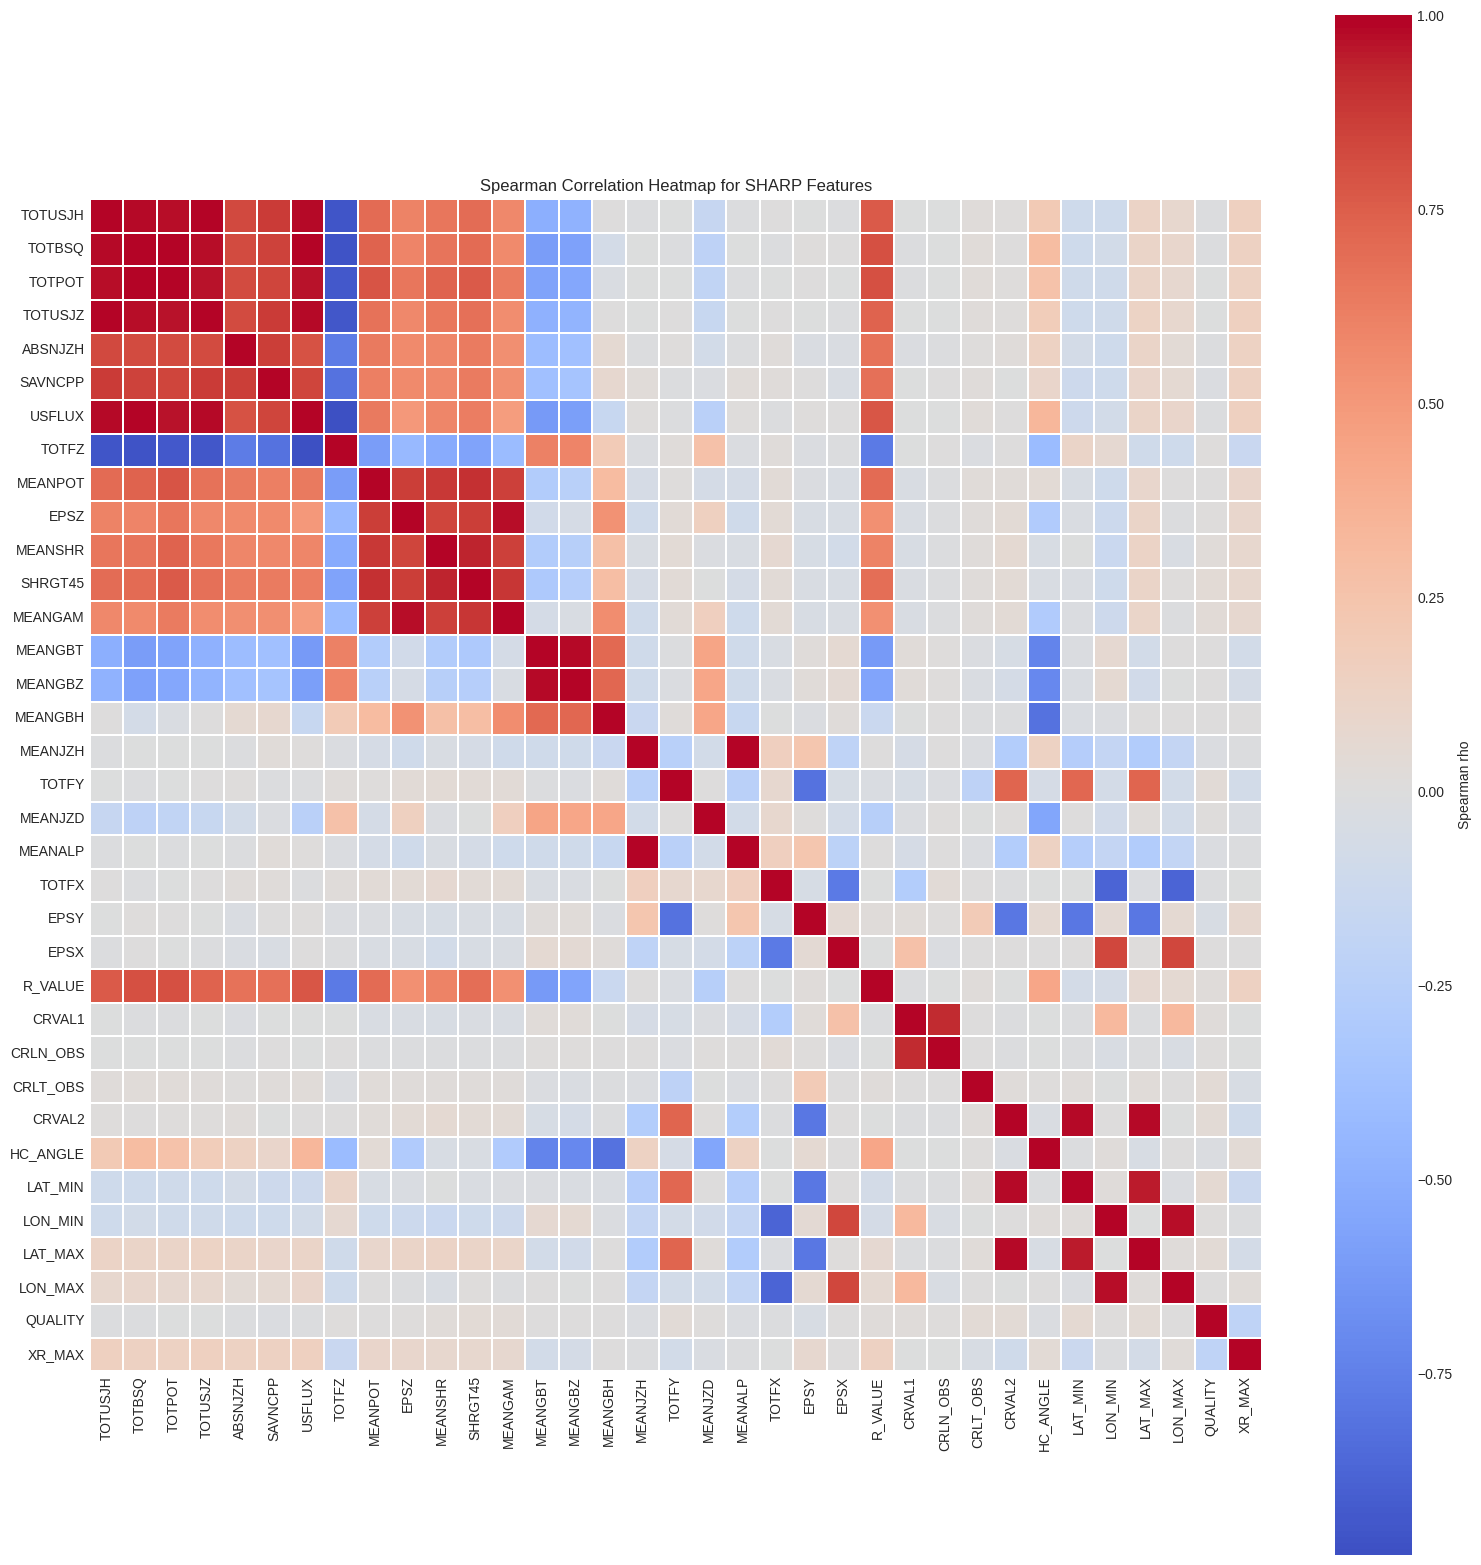

Most correlated SHARP feature pair:
  TOTUSJH vs TOTUSJZ -> Spearman rho = 0.996
Physical interpretation: strong correlations often appear when two SHARP parameters measure related aspects of magnetic complexity, such as total flux, current, or shear integrated over the same active region.

Least correlated SHARP feature pair:
  LON_MAX vs MEANGBZ -> Spearman rho = 0.000
Physical interpretation: weak correlations suggest the two quantities capture different physical properties of the active region, for example overall magnetic flux versus localized geometric or current-related structure.

Top 10 SHARP features by absolute point-biserial correlation with flare_binary:
   feature  point_biserial_r        p_value
0  TOTUSJH          0.252373   0.000000e+00
1  ABSNJZH          0.249356   0.000000e+00
2  SAVNCPP          0.238357   0.000000e+00
3   TOTBSQ          0.232845   0.000000e+00
4  TOTUSJZ          0.225276   0.000000e+00
5   USFLUX          0.209234   0.000000e+00
6    TOTFZ      

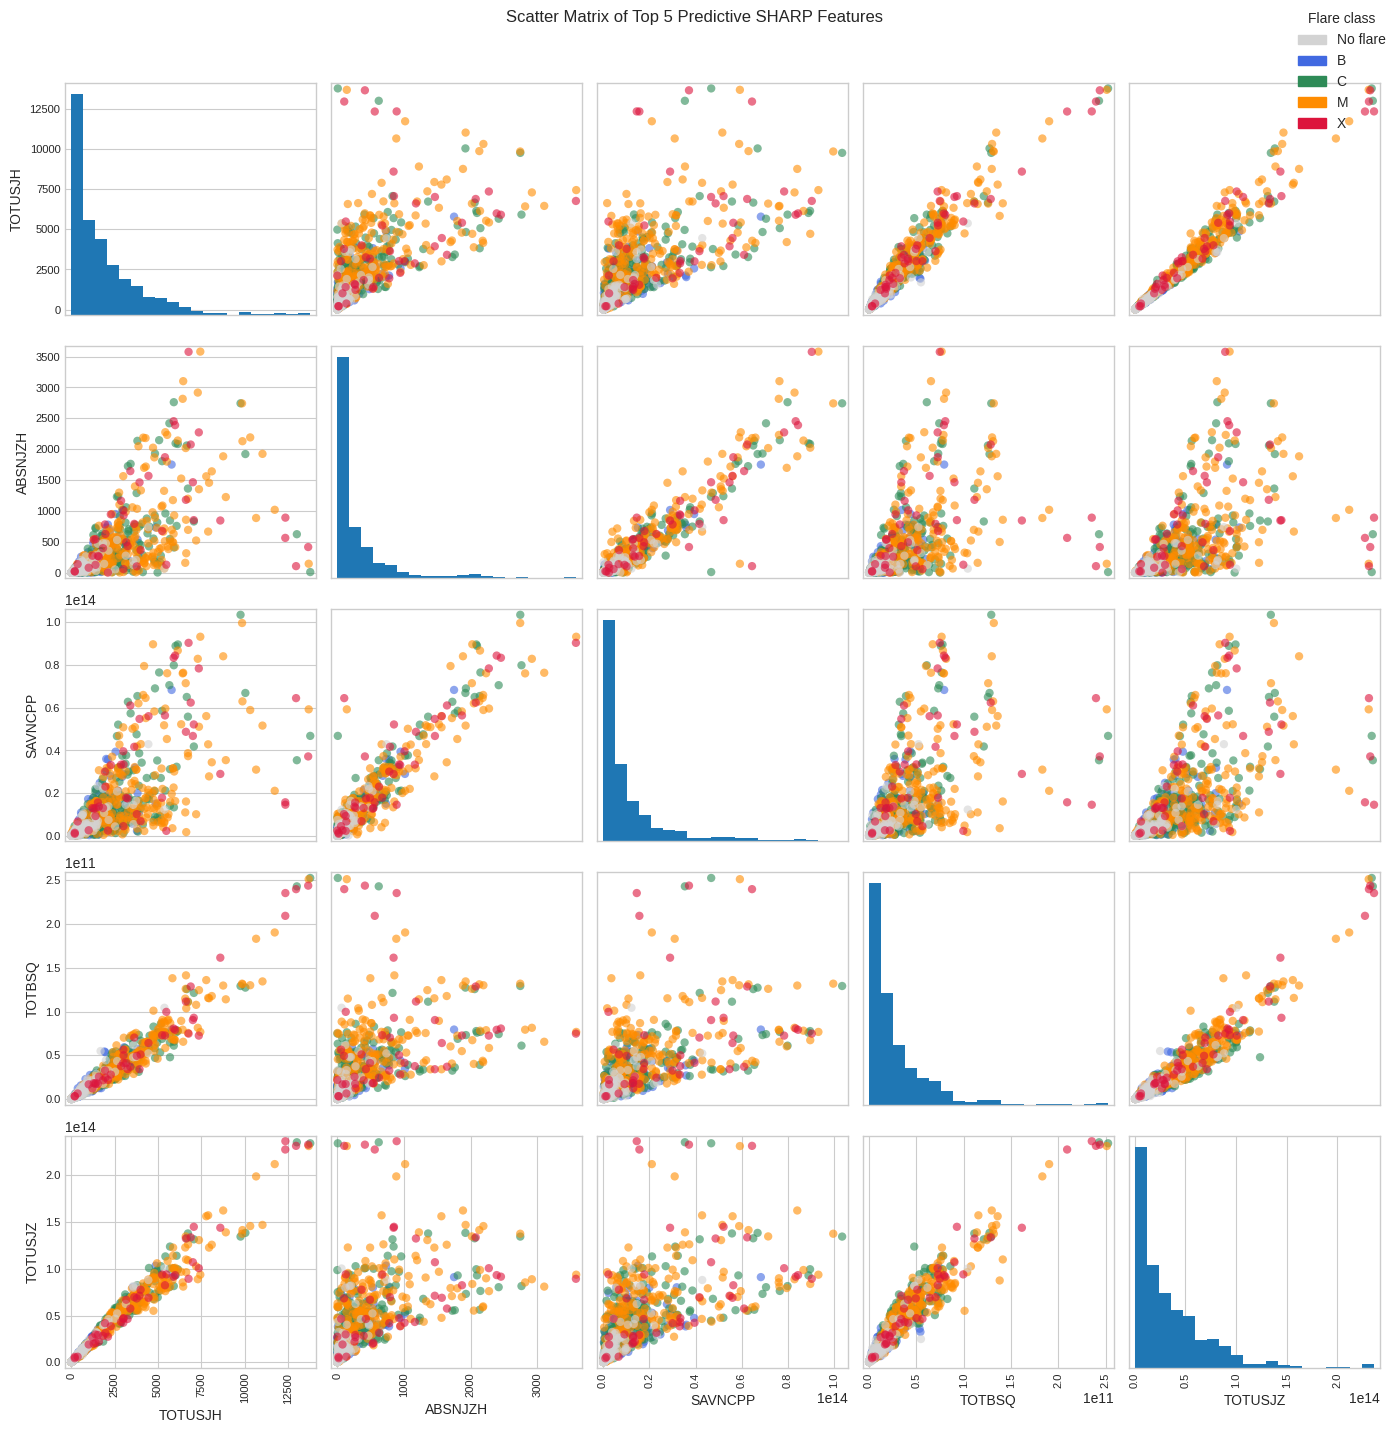

9625

In [ ]:
# 15-19. Correlation analysis for SHARP features and flare predictiveness
from matplotlib.patches import Patch

# Create a binary target if it does not already exist
if "flare_binary" not in df_preprocessed.columns:
    df_preprocessed["flare_binary"] = df_preprocessed["flare_class"].isin(["M", "X"]).astype("int8")

# Select numeric SHARP-like features and exclude label/helper columns
exclude_cols = {
    "Unnamed: 0",
    "BFLARE", "CFLARE", "MFLARE", "XFLARE",
    "BFLARE_LOC", "CFLARE_LOC", "MFLARE_LOC", "XFLARE_LOC",
    "XR_QUAL", "SHARPnum", "flare_binary"
}
numeric_features = [
    col for col in df_preprocessed.select_dtypes(include="number").columns
    if col not in exclude_cols
 ]

correlation_source = df_preprocessed[numeric_features + ["flare_binary", "flare_class"]].reset_index()
correlation_df = stratified_sample(
    correlation_source,
    group_col="flare_class",
    max_total_rows=120000,
    min_per_group=2000,
    random_state=42,
 )
print(f"Correlation analysis uses a stratified sample of {len(correlation_df):,} rows.")

# 15. Spearman correlation matrix for SHARP features
spearman_corr = correlation_df[numeric_features].corr(method="spearman")

# 16. Heatmap of the Spearman correlation matrix
plt.figure(figsize=(max(12, len(numeric_features) * 0.45), max(10, len(numeric_features) * 0.45)))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"label": "Spearman rho"}
 )
plt.title("Spearman Correlation Heatmap for SHARP Features")
plt.tight_layout()
plt.show()

# 17. Most and least correlated feature pairs (excluding the diagonal)
corr_pairs = spearman_corr.where(~np.eye(len(spearman_corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

most_correlated_pair = corr_pairs.abs().idxmax()
least_correlated_pair = corr_pairs.abs().idxmin()

most_corr_value = corr_pairs.loc[most_correlated_pair]
least_corr_value = corr_pairs.loc[least_correlated_pair]

print("Most correlated SHARP feature pair:")
print(f"  {most_correlated_pair[0]} vs {most_correlated_pair[1]} -> Spearman rho = {most_corr_value:.3f}")
print("Physical interpretation: strong correlations often appear when two SHARP parameters measure related aspects of magnetic complexity, such as total flux, current, or shear integrated over the same active region.")

print("\nLeast correlated SHARP feature pair:")
print(f"  {least_correlated_pair[0]} vs {least_correlated_pair[1]} -> Spearman rho = {least_corr_value:.3f}")
print("Physical interpretation: weak correlations suggest the two quantities capture different physical properties of the active region, for example overall magnetic flux versus localized geometric or current-related structure.")

# 18. Point-biserial correlation between each SHARP feature and flare_binary
correlation_rows = []
for feature in numeric_features:
    valid_rows = correlation_df[[feature, "flare_binary"]].dropna()
    if valid_rows[feature].nunique() > 1:
        corr, p_value = pointbiserialr(valid_rows["flare_binary"], valid_rows[feature])
        correlation_rows.append({
            "feature": feature,
            "point_biserial_r": corr,
            "abs_r": abs(corr),
            "p_value": p_value,
        })

point_biserial_table = pd.DataFrame(correlation_rows).sort_values(
    by="abs_r", ascending=False
 ).reset_index(drop=True)

top_features = point_biserial_table.head(10)
print("\nTop 10 SHARP features by absolute point-biserial correlation with flare_binary:")
print(top_features[["feature", "point_biserial_r", "p_value"]])

selected_features = top_features["feature"].head(5).tolist()
print("\nMost predictive features based on this metric:")
print(selected_features)

# 19. Scatter matrix for the top 5 predictive features, colored by flare class
scatter_sample = pd.concat(
    [
        group.sample(n=min(len(group), 250), random_state=42)
        for _, group in correlation_df.groupby("flare_class", observed=False)
    ],
    ignore_index=True
 )

color_map = {
    "No flare": "lightgray",
    "B": "royalblue",
    "C": "seagreen",
    "M": "darkorange",
    "X": "crimson",
}
scatter_colors = scatter_sample["flare_class"].astype(str).map(color_map).fillna("black")

axes = pd.plotting.scatter_matrix(
    scatter_sample[selected_features],
    figsize=(14, 14),
    diagonal="hist",
    c=scatter_colors,
    alpha=0.6,
    marker="o",
    hist_kwds={"bins": 20}
 )
fig = axes[0, 0].figure
legend_handles = [
    Patch(color=color_map[flare_class], label=flare_class)
    for flare_class in ["No flare", "B", "C", "M", "X"]
    if flare_class in scatter_sample["flare_class"].astype(str).unique()
 ]
fig.legend(handles=legend_handles, loc="upper right", title="Flare class")
fig.suptitle("Scatter Matrix of Top 5 Predictive SHARP Features", y=1.02)
plt.tight_layout()
plt.show()

del correlation_source, correlation_df, scatter_sample
gc.collect()

### Parameters distribution


20.	Plot box plots for the top 5 predictive features, grouped by flare class.
21.	Plot violin plots for the same features. What do they reveal that box plots do not?
22.	For USFLUX, test whether flaring vs. non-flaring distributions are significantly different using scipy.stats.mannwhitneyu(). Interpret the p-value.


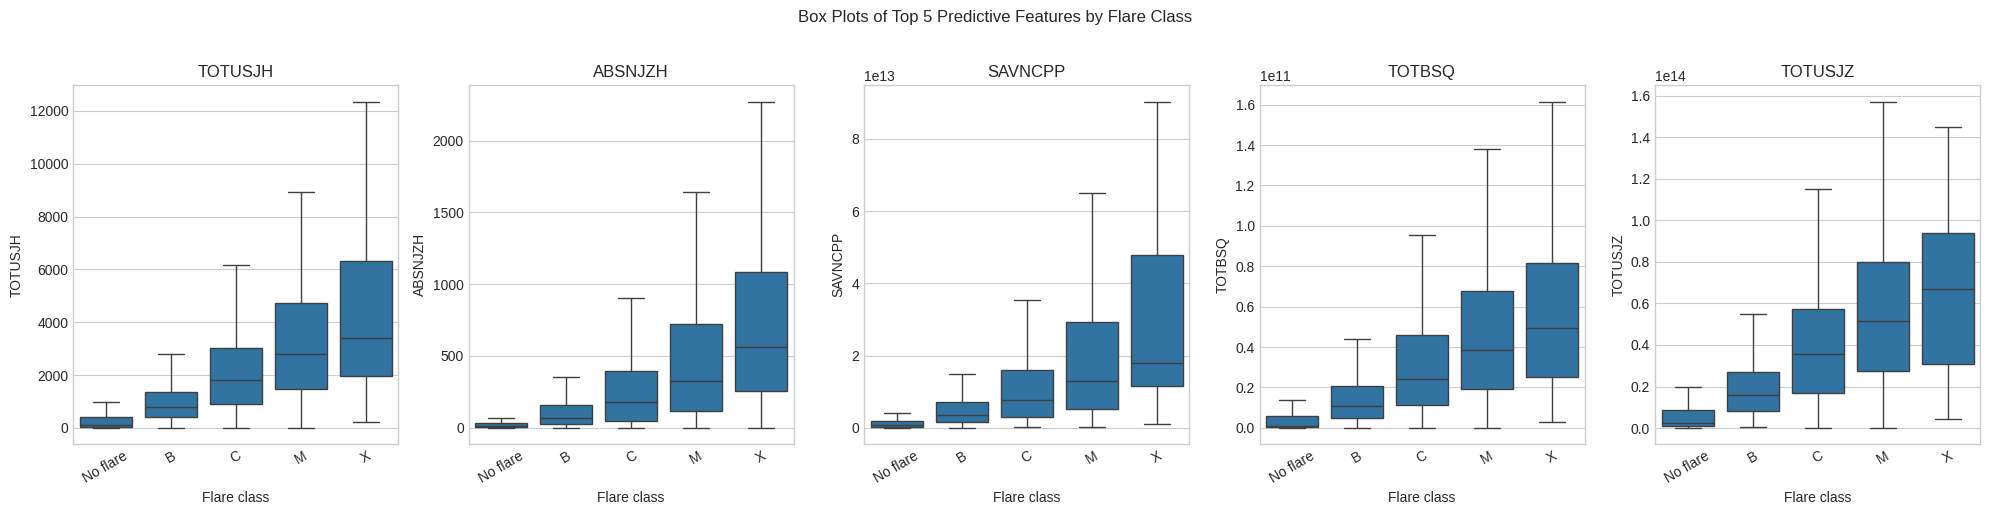

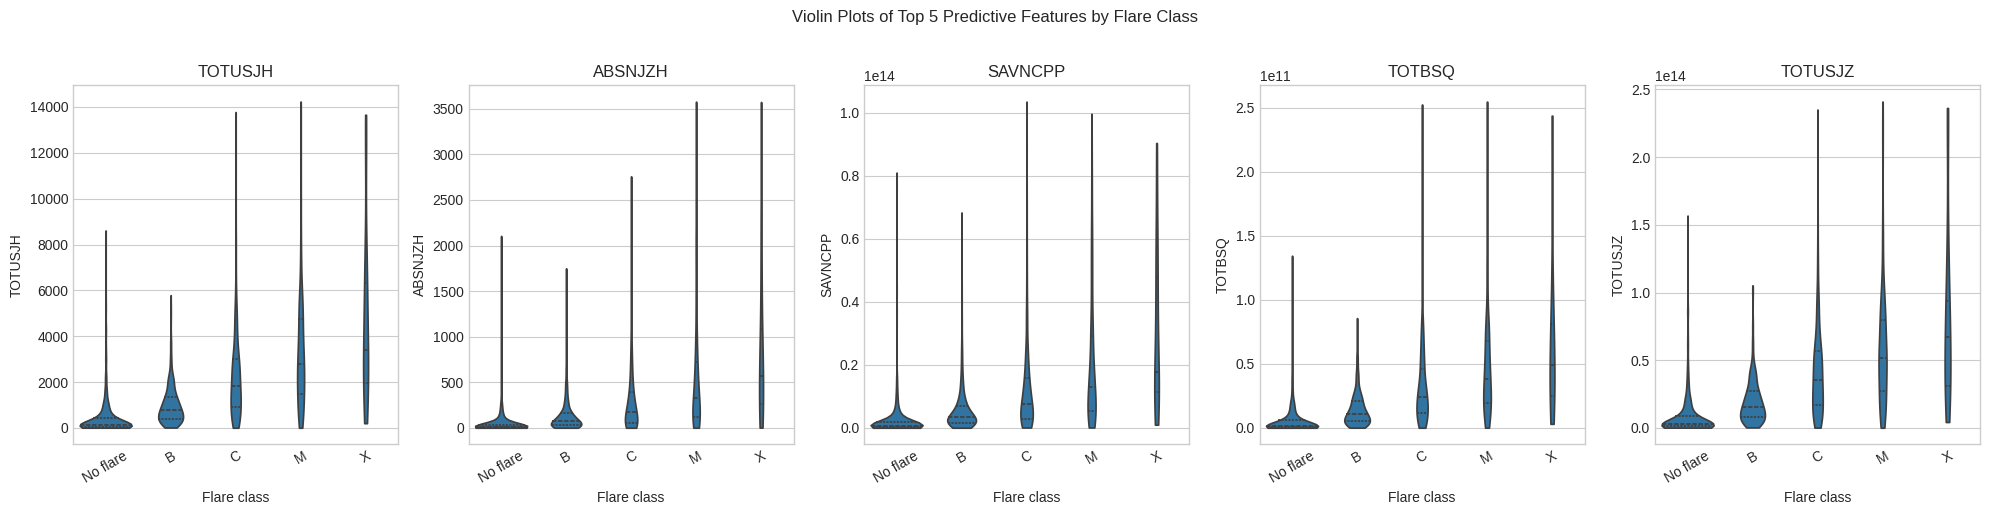

Violin plots reveal distribution shape, density, skewness, and possible multimodality within each flare class.
Box plots summarize medians and quartiles, but they do not show whether the data have multiple peaks or where observations are most concentrated.

Mann-Whitney U statistic for USFLUX: 6.786e+07
p-value: 0.000e+00
Interpretation: the USFLUX distributions for flaring and non-flaring observations are significantly different.


69867

In [ ]:
# 20-22. Distribution plots for the top predictive features and a Mann-Whitney U test
# Recreate flare_binary if needed
if "flare_binary" not in df_preprocessed.columns:
    df_preprocessed["flare_binary"] = df_preprocessed["flare_class"].isin(["M", "X"]).astype("int8")

# Use the top 5 predictive features from the previous correlation analysis
if "top_features" in globals():
    selected_features = top_features["feature"].head(5).tolist()
else:
    selected_features = ["ABSNJZH", "TOTUSJH", "SAVNCPP", "TOTBSQ", "USFLUX"]

# Use a balanced sample per class for plotting so rare classes remain visible
plot_source = df_preprocessed.reset_index()
plot_sample = pd.concat(
    [
        group.sample(n=min(len(group), 800), random_state=42)
        for _, group in plot_source.groupby("flare_class", observed=False)
    ],
    ignore_index=True
)

class_order = [
    flare_class
    for flare_class in ["No flare", "B", "C", "M", "X"]
    if flare_class in plot_sample["flare_class"].unique()
 ]

# 20. Box plots with one axis per feature
fig, axes = plt.subplots(1, len(selected_features), figsize=(4 * len(selected_features), 5))
if len(selected_features) == 1:
    axes = [axes]

for axis, feature in zip(axes, selected_features):
    sns.boxplot(
        data=plot_sample,
        x="flare_class",
        y=feature,
        order=class_order,
        showfliers=False,
        ax=axis
    )
    axis.set_title(feature)
    axis.set_xlabel("Flare class")
    axis.tick_params(axis="x", rotation=30)

fig.suptitle("Box Plots of Top 5 Predictive Features by Flare Class", y=1.02)
plt.tight_layout()
plt.show()

# 21. Violin plots with one axis per feature
fig, axes = plt.subplots(1, len(selected_features), figsize=(4 * len(selected_features), 5))
if len(selected_features) == 1:
    axes = [axes]

for axis, feature in zip(axes, selected_features):
    sns.violinplot(
        data=plot_sample,
        x="flare_class",
        y=feature,
        order=class_order,
        cut=0,
        inner="quartile",
        ax=axis
    )
    axis.set_title(feature)
    axis.set_xlabel("Flare class")
    axis.tick_params(axis="x", rotation=30)

fig.suptitle("Violin Plots of Top 5 Predictive Features by Flare Class", y=1.02)
plt.tight_layout()
plt.show()

print("Violin plots reveal distribution shape, density, skewness, and possible multimodality within each flare class.")
print("Box plots summarize medians and quartiles, but they do not show whether the data have multiple peaks or where observations are most concentrated.")

# 22. Mann-Whitney U test for flaring vs non-flaring USFLUX values
non_flaring_usflux = df_preprocessed.loc[df_preprocessed["flare_binary"] == 0, "USFLUX"].dropna()
flaring_usflux = df_preprocessed.loc[df_preprocessed["flare_binary"] == 1, "USFLUX"].dropna()

usflux_test_sample = 100000
if len(non_flaring_usflux) > usflux_test_sample:
    non_flaring_usflux = non_flaring_usflux.sample(n=usflux_test_sample, random_state=42)
if len(flaring_usflux) > usflux_test_sample:
    flaring_usflux = flaring_usflux.sample(n=usflux_test_sample, random_state=42)

u_stat, p_value = mannwhitneyu(
    flaring_usflux,
    non_flaring_usflux,
    alternative="two-sided"
)

print(f"\nMann-Whitney U statistic for USFLUX: {u_stat:.3e}")
print(f"p-value: {p_value:.3e}")

if p_value < 0.05:
    print("Interpretation: the USFLUX distributions for flaring and non-flaring observations are significantly different.")
else:
    print("Interpretation: there is no statistically significant difference between the two USFLUX distributions.")

del plot_source, plot_sample
gc.collect()

### Gaussian Mixture Model

Use a Gaussian Mixture Model (GMM, an unsupervised clustering method) to identify groups of active-region observations based on SHARP parameters, and then inspect whether these groups are related to flare activity.

23. Separate SHARP parameters from labels

GMM analysis uses a stratified sample of 120,000 rows.
Fitting GMM on 25,000 sampled rows, then predicting the full GMM sample.
GMM cluster counts:
GMM_cluster
0    12396
1    63449
2    44155
Name: count, dtype: int64

Flare class counts within each GMM cluster:
flare_class     B     C    M  No flare   X
GMM_cluster                               
0             487  1232  533     10107  37
1            1380   634  123     61306   6
2              76    70   19     43990   0

Flare class fractions within each GMM cluster:
flare_class      B      C      M  No flare      X
GMM_cluster                                      
0            0.039  0.099  0.043     0.815  0.003
1            0.022  0.010  0.002     0.966  0.000
2            0.002  0.002  0.000     0.996  0.000

M/X flare rate by cluster:
GMM_cluster
0    0.046
1    0.002
2    0.000
Name: flare_binary, dtype: float64


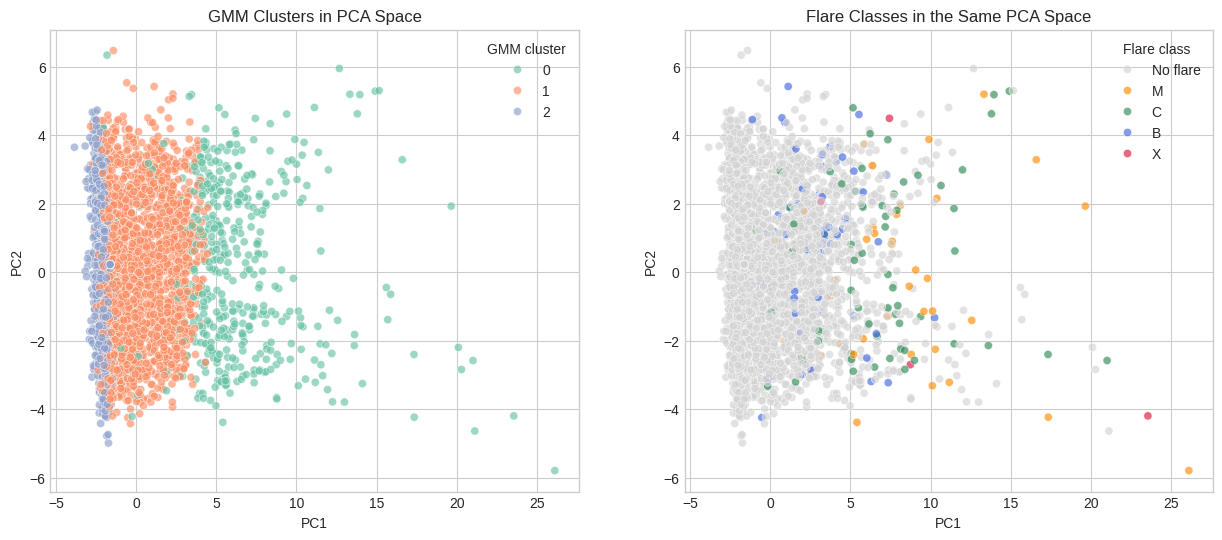

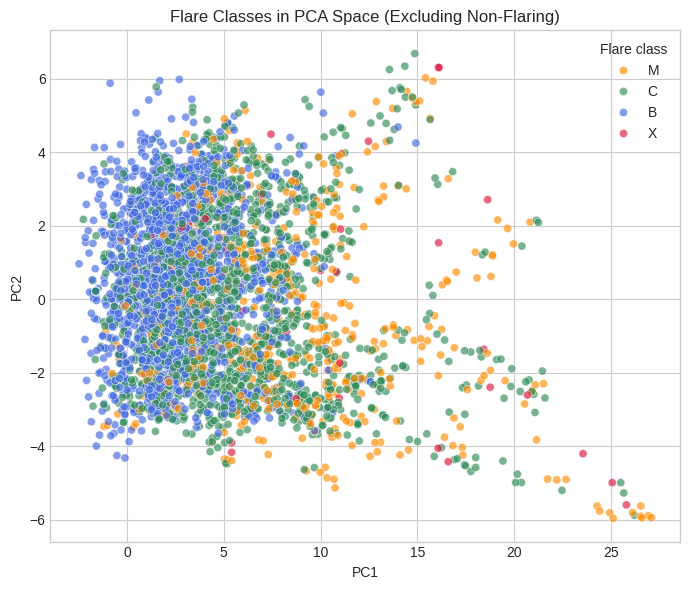


Mean SHARP parameters by GMM cluster for selected high-interest features:
Empty DataFrame
Columns: [ABSNJZH, TOTUSJH, SAVNCPP, TOTBSQ, TOTUSJZ, USFLUX, R_VALUE]
Index: []

Cluster 0 has the highest M/X flare rate.
Clusters with higher flare rates typically also show larger averages in total flux, current, and helicity-related SHARP parameters, which is consistent with stronger magnetic complexity in flare-productive active regions.


26733

In [ ]:
# 23-25. Gaussian Mixture Model clustering of SHARP parameters
# Reuse the SHARP feature list from the correlation analysis, or rebuild it if needed
if "numeric_features" not in globals():
    exclude_cols = {
        "Unnamed: 0",
        "BFLARE", "CFLARE", "MFLARE", "XFLARE",
        "BFLARE_LOC", "CFLARE_LOC", "MFLARE_LOC", "XFLARE_LOC",
        "XR_QUAL", "SHARPnum", "flare_binary"
    }
    numeric_features = [
        col for col in df_preprocessed.select_dtypes(include="number").columns
        if col not in exclude_cols
    ]

if "flare_binary" not in df_preprocessed.columns:
    df_preprocessed["flare_binary"] = df_preprocessed["flare_class"].isin(["M", "X"]).astype("int8")

gmm_source_df = stratified_sample(
    df_preprocessed[numeric_features + ["flare_class", "flare_binary"]],
    group_col="flare_class",
    max_total_rows=120000,
    min_per_group=2000,
    random_state=42,
 )
print(f"GMM analysis uses a stratified sample of {len(gmm_source_df):,} rows.")

# 23. Separate SHARP parameters from labels and standardize them
sharp_features = gmm_source_df[numeric_features].to_numpy(dtype=np.float32, copy=True)
scaler = StandardScaler()
SHARP_scaled = scaler.fit_transform(sharp_features)

# Fitting GMM on the full sample is still expensive, so fit on a representative subset
gmm_fit_sample_size = min(len(gmm_source_df), 25000)
if len(gmm_source_df) > gmm_fit_sample_size:
    fit_indices = np.random.default_rng(42).choice(len(gmm_source_df), size=gmm_fit_sample_size, replace=False)
    SHARP_scaled_fit = SHARP_scaled[fit_indices]
    print(f"Fitting GMM on {gmm_fit_sample_size:,} sampled rows, then predicting the full GMM sample.")
else:
    SHARP_scaled_fit = SHARP_scaled
    print(f"Fitting GMM on all {len(gmm_source_df):,} sampled rows.")

gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
 )
gmm.fit(SHARP_scaled_fit)
gmm_clusters = gmm.predict(SHARP_scaled).astype(np.int8)

gmm_results = pd.DataFrame({
    "flare_class": gmm_source_df["flare_class"].to_numpy(),
    "flare_binary": gmm_source_df["flare_binary"].to_numpy(),
    "GMM_cluster": gmm_clusters,
})

print("GMM cluster counts:")
print(gmm_results["GMM_cluster"].value_counts().sort_index())

# Compare flare labels inside each GMM cluster
cluster_flare_counts = pd.crosstab(
    gmm_results["GMM_cluster"],
    gmm_results["flare_class"]
 )
cluster_flare_table = pd.crosstab(
    gmm_results["GMM_cluster"],
    gmm_results["flare_class"],
    normalize="index"
 )

print("\nFlare class counts within each GMM cluster:")
print(cluster_flare_counts)

print("\nFlare class fractions within each GMM cluster:")
print(cluster_flare_table.round(3))

cluster_flare_rate = gmm_results.groupby("GMM_cluster")["flare_binary"].mean().sort_values(ascending=False)
print("\nM/X flare rate by cluster:")
print(cluster_flare_rate.round(3))

# 24. Visualize the clusters in a 2D PCA projection and overlay flare labels
gmm_pca = PCA(n_components=2, random_state=42)
gmm_embedding = gmm_pca.fit_transform(SHARP_scaled)

plot_df = pd.DataFrame({
    "PC1": gmm_embedding[:, 0],
    "PC2": gmm_embedding[:, 1],
    "GMM_cluster": gmm_clusters,
    "flare_class": gmm_results["flare_class"].to_numpy(),
})

cluster_palette = sns.color_palette("Set2", n_colors=gmm.n_components)
flare_palette = {
    "No flare": "lightgray",
    "B": "royalblue",
    "C": "seagreen",
    "M": "darkorange",
    "X": "crimson",
}

plot_sample = plot_df.sample(n=min(len(plot_df), 4000), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(
    data=plot_sample,
    x="PC1",
    y="PC2",
    hue="GMM_cluster",
    palette=cluster_palette,
    alpha=0.65,
    s=35,
    ax=axes[0]
 )
axes[0].set_title("GMM Clusters in PCA Space")
axes[0].legend(title="GMM cluster")

sns.scatterplot(
    data=plot_sample,
    x="PC1",
    y="PC2",
    hue="flare_class",
    palette=flare_palette,
    alpha=0.65,
    s=35,
    ax=axes[1]
 )
axes[1].set_title("Flare Classes in the Same PCA Space")
axes[1].legend(title="Flare class")

flare_only_plot = plot_df.loc[plot_df["flare_class"] != "No flare"]
flare_only_plot = flare_only_plot.sample(n=min(len(flare_only_plot), 4000), random_state=42)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=flare_only_plot,
    x="PC1",
    y="PC2",
    hue="flare_class",
    palette=flare_palette,
    alpha=0.65,
    s=35
 )
plt.title("Flare Classes in PCA Space (Excluding Non-Flaring)")
plt.legend(title="Flare class")

plt.tight_layout()
plt.show()

# 25. Inspect which SHARP parameters are strongest in flare-rich clusters
top_summary_features = [
    feature for feature in ["ABSNJZH", "TOTUSJH", "SAVNCPP", "TOTBSQ", "TOTUSJZ", "USFLUX", "R_VALUE"]
    if feature in gmm_source_df.columns
]
cluster_feature_summary = gmm_source_df[top_summary_features].groupby(gmm_results["GMM_cluster"]).mean()

print("\nMean SHARP parameters by GMM cluster for selected high-interest features:")
print(cluster_feature_summary.round(3))

flare_rich_cluster = cluster_flare_rate.idxmax()
print(f"\nCluster {flare_rich_cluster} has the highest M/X flare rate.")
print("Clusters with higher flare rates typically also show larger averages in total flux, current, and helicity-related SHARP parameters, which is consistent with stronger magnetic complexity in flare-productive active regions.")

del sharp_features, SHARP_scaled, SHARP_scaled_fit, gmm_source_df, plot_df, plot_sample, flare_only_plot
gc.collect()

24. Visualize the results and overlay flare labels
25. Inspect your results:
*   Do flaring and non-flaring observations occupy different GMM clusters?
*   Are M- and X-class flares concentrated in one cluster?
*   Which SHARP parameters have high values in flare-rich clusters?
*   Are some clusters physically interpretable, e.g., empirical parameters is high / low in the selected cluster?  






## Dimensionality Reduction

**N.B.**: Always standardize your data before applying the following algorithms to prevent scale-dependent features from dominating distance calculations, optimization, or variance-based components of the model.

You can explore different (methods)[https://scikit-learn.org/stable/modules/preprocessing.html]

### PCA
23.	Apply PCA. Plot the explained variance ratio per component (scree plot).
24.	How many components are needed to explain 90% of the variance?
25.	Project the data onto the first 2 PCs and create a scatter plot coloured by flare class. Are the classes visually separable?
26.	Inspect the loadings (eigenvectors) of PC1 and PC2. Which original SHARP features contribute most?


PCA and downstream clustering use a stratified sample of 150,000 rows.


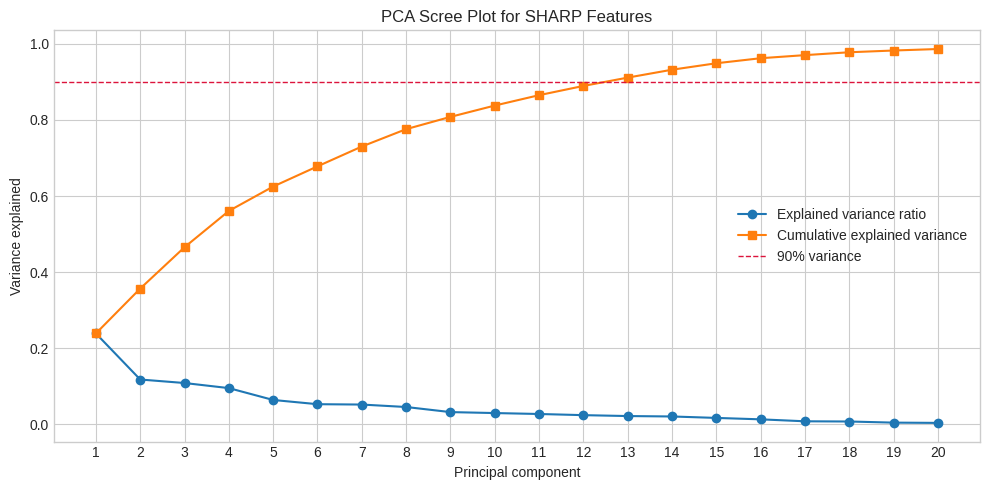

Number of components needed to explain 90% of the variance: 13
Cumulative explained variance at that point: 0.911


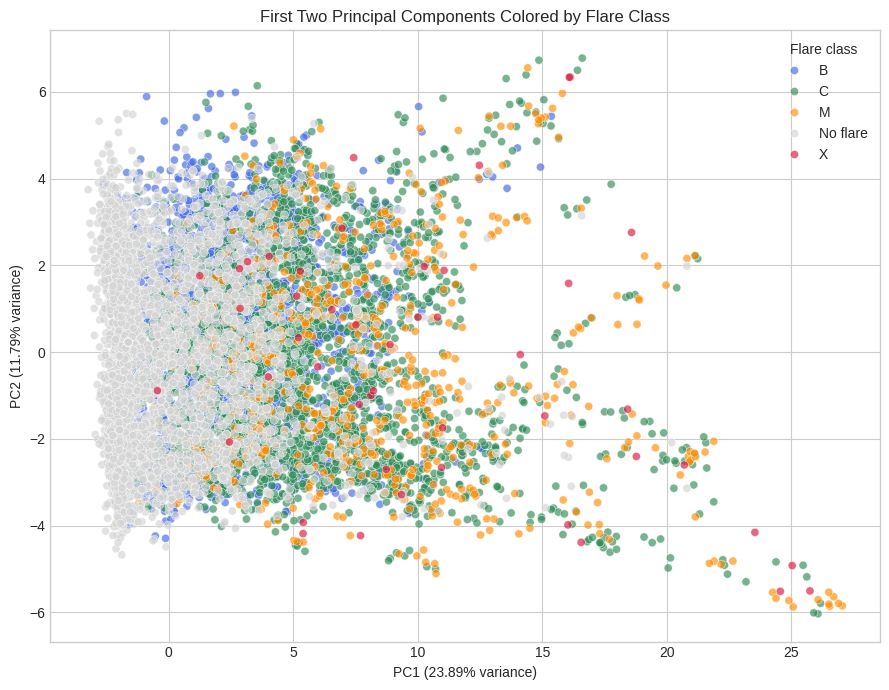

Visual interpretation:
The flare classes show partial overlap in the first two PCs, so PCA gives some structure but not clean class separation in 2D.
That is expected because PCA maximizes variance, not class discrimination.

Top contributors to PC1:
         PC1_loading  PC2_loading
TOTBSQ      0.312511    -0.013844
TOTUSJH     0.312349    -0.010795
TOTUSJZ     0.310143    -0.005959
USFLUX      0.309073    -0.037619
TOTFZ      -0.274447     0.063985
R_VALUE     0.267062    -0.018782
SHRGT45     0.265248     0.108401
MEANSHR     0.259200     0.119488
SAVNCPP     0.258039     0.003694
EPSZ        0.256774     0.143343

Top contributors to PC2:
          PC1_loading  PC2_loading
CRVAL2      -0.018327     0.426977
LAT_MAX      0.014201     0.426969
LAT_MIN     -0.048042     0.419354
EPSY         0.006883    -0.362454
MEANALP      0.007388    -0.237897
MEANJZH      0.001896    -0.231792
TOTFY       -0.067065     0.231178
MEANGBH      0.001210     0.178761
HC_ANGLE     0.072645    -0.171035

In [ ]:
# 23-26. PCA on SHARP features
# Reuse the SHARP feature set from earlier analysis, or rebuild it if needed
if "numeric_features" not in globals():
    exclude_cols = {
        "Unnamed: 0",
        "BFLARE", "CFLARE", "MFLARE", "XFLARE",
        "BFLARE_LOC", "CFLARE_LOC", "MFLARE_LOC", "XFLARE_LOC",
        "XR_QUAL", "SHARPnum", "flare_binary"
    }
    numeric_features = [
        col for col in df_preprocessed.select_dtypes(include="number").columns
        if col not in exclude_cols
    ]

pca_source_df = stratified_sample(
    df_preprocessed[numeric_features + ["flare_class"]],
    group_col="flare_class",
    max_total_rows=150000,
    min_per_group=3000,
    random_state=42,
 )
pca_source_df = pca_source_df.copy()
pca_source_df["flare_binary"] = pca_source_df["flare_class"].isin(["M", "X"]).astype("int8")

X = pca_source_df[numeric_features].to_numpy(dtype=np.float32, copy=True)
y = pca_source_df["flare_class"].reset_index(drop=True)

print(f"PCA and downstream clustering use a stratified sample of {len(pca_source_df):,} rows.")

# A few settings are left visible so you can experiment with them
max_components_to_plot = min(20, len(numeric_features))
pca_sample_size = 4000

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 23. Fit PCA and plot the explained variance ratio (scree plot)
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
components = np.arange(1, max_components_to_plot + 1)
plt.plot(
    components,
    explained_variance_ratio[:max_components_to_plot],
    marker="o",
    label="Explained variance ratio"
 )
plt.plot(
    components,
    cumulative_explained_variance[:max_components_to_plot],
    marker="s",
    label="Cumulative explained variance"
 )
plt.axhline(0.90, color="crimson", linestyle="--", linewidth=1, label="90% variance")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.title("PCA Scree Plot for SHARP Features")
plt.xticks(components)
plt.legend()
plt.tight_layout()
plt.show()

# 24. Number of components needed to explain 90% of the variance
n_components_90 = np.argmax(cumulative_explained_variance >= 0.90) + 1
print(f"Number of components needed to explain 90% of the variance: {n_components_90}")
print(f"Cumulative explained variance at that point: {cumulative_explained_variance[n_components_90 - 1]:.3f}")

# 25. Project onto the first 2 PCs and visualize by flare class
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2d.fit_transform(X_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2[:, 0],
    "PC2": X_pca_2[:, 1],
    "flare_class": y.values
})

plot_sample = pd.concat(
    [
        group.sample(n=min(len(group), pca_sample_size), random_state=42)
        for _, group in pca_plot_df.groupby("flare_class", observed=False)
    ],
    ignore_index=True
 )

flare_palette = {
    "No flare": "lightgray",
    "B": "royalblue",
    "C": "seagreen",
    "M": "darkorange",
    "X": "crimson",
}

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=plot_sample,
    x="PC1",
    y="PC2",
    hue="flare_class",
    palette=flare_palette,
    alpha=0.65,
    s=35
 )
plt.title("First Two Principal Components Colored by Flare Class")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)")
plt.legend(title="Flare class")
plt.tight_layout()
plt.show()

print("Visual interpretation:")
print("The flare classes show partial overlap in the first two PCs, so PCA gives some structure but not clean class separation in 2D.")
print("That is expected because PCA maximizes variance, not class discrimination.")

# 26. Inspect the loadings of PC1 and PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=numeric_features,
    columns=["PC1_loading", "PC2_loading"]
 )

top_pc1 = loadings["PC1_loading"].abs().sort_values(ascending=False).head(10)
top_pc2 = loadings["PC2_loading"].abs().sort_values(ascending=False).head(10)

print("\nTop contributors to PC1:")
print(loadings.loc[top_pc1.index].sort_values("PC1_loading", key=lambda column: column.abs(), ascending=False))

print("\nTop contributors to PC2:")
print(loadings.loc[top_pc2.index].sort_values("PC2_loading", key=lambda column: column.abs(), ascending=False))

# Optional: uncomment and change the number below if you want to inspect more PCs
# PCA(n_components=5, random_state=42).fit(X_scaled).explained_variance_ratio_

###t-SNE
28.	Apply TSNE(n_components=2, perplexity=30) to the standardised features.
29.	Plot the 2D t-SNE embedding coloured by flare class.
30.	How does t-SNE compare to PCA for class separation? What are the trade-offs?


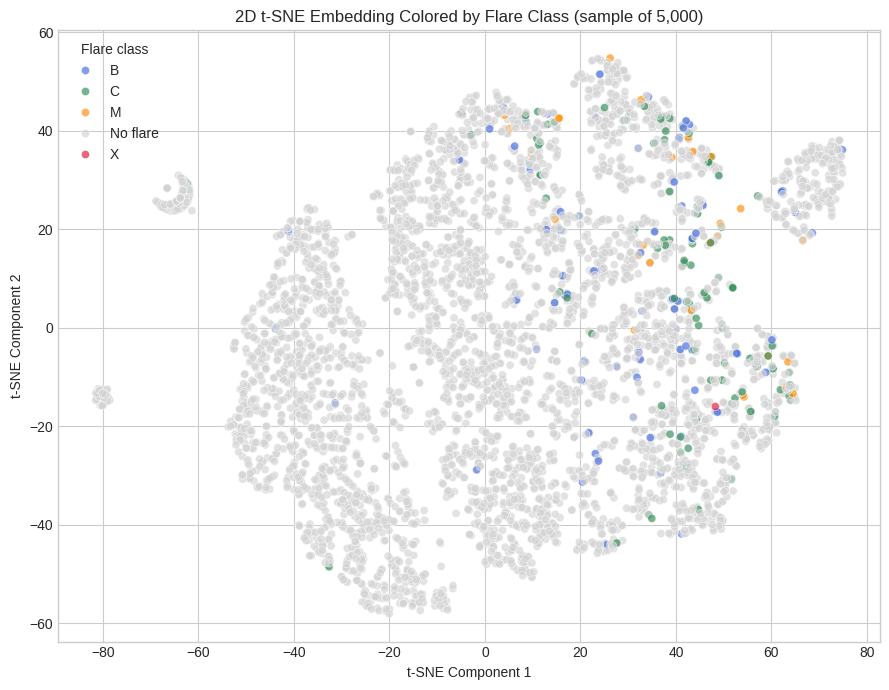

t-SNE was fit on a representative sample to keep runtime reasonable in Google Colab.


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse X_scaled and y from the PCA section
# X_scaled (standardized features) and y (flare_class) are already defined.

t_sne_fit_sample_size = min(len(X_scaled), 5000)

# 28. Apply t-SNE to a representative sample of the standardized features
tsne_sample_idx = np.random.default_rng(42).choice(len(X_scaled), size=t_sne_fit_sample_size, replace=False)
X_tsne_input = X_scaled[tsne_sample_idx]
y_tsne = y.iloc[tsne_sample_idx].reset_index(drop=True)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_input)

# Create a DataFrame for plotting
tsne_plot_df = pd.DataFrame({
    "TSNE1": X_tsne[:, 0],
    "TSNE2": X_tsne[:, 1],
    "flare_class": y_tsne.values
})

# Use the same flare_palette as in PCA for consistency
flare_palette = {
    "No flare": "lightgray",
    "B": "royalblue",
    "C": "seagreen",
    "M": "darkorange",
    "X": "crimson",
}

# 29. Plot the 2D t-SNE embedding coloured by flare class
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=tsne_plot_df,
    x="TSNE1",
    y="TSNE2",
    hue="flare_class",
    palette=flare_palette,
    alpha=0.65,
    s=35
)
plt.title(f"2D t-SNE Embedding Colored by Flare Class (sample of {t_sne_fit_sample_size:,})")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Flare class")
plt.tight_layout()
plt.show()

print("t-SNE was fit on a representative sample to keep runtime reasonable in Google Colab.")

## Clustering

###K-Means
31.	Apply K-Means to the first 5 PCA components. Try k = 2, 3, 4, 5. The optimal amount of kernels can be identified by needle method.
32.	Plot the inertia (elbow curve) and silhouette score vs. k. What is the optimal k?
33.	Visualise clusters in the PCA 2D space.
34.	For each cluster, compute the flare rate (fraction of observations that are M/X flares). Do clusters correspond to physical activity levels?



Evaluating K-Means on the sampled PCA dataset with 150,000 rows...
  k=2: Inertia=2424429.50, Silhouette Score=0.333
  k=3: Inertia=2075808.12, Silhouette Score=0.218
  k=4: Inertia=1763621.88, Silhouette Score=0.236
  k=5: Inertia=1528004.38, Silhouette Score=0.260


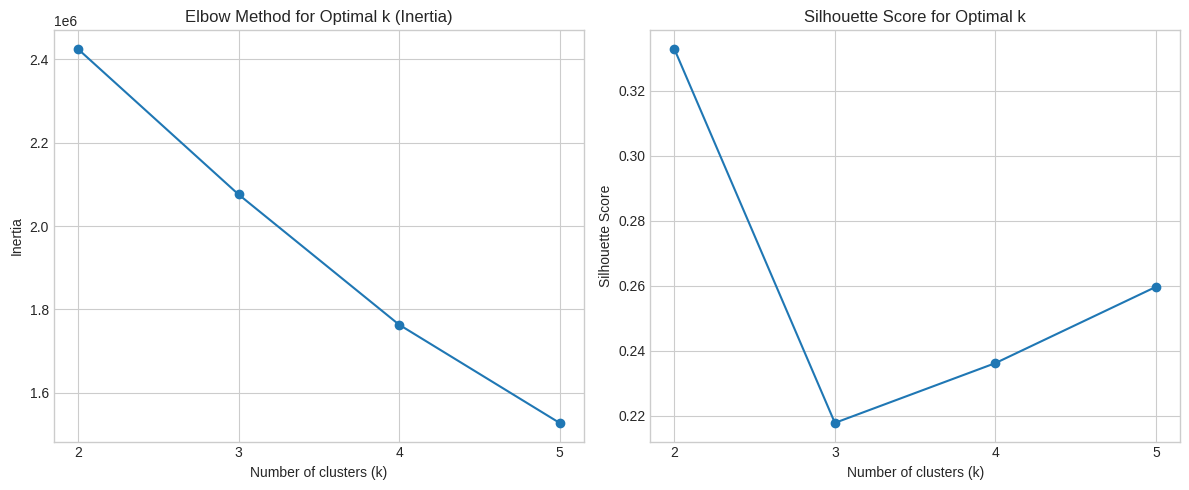


Optimal k based on Elbow Method (visual inspection): Observe the elbow point where the decrease in inertia starts to slow down significantly.
Optimal k based on Silhouette Score (highest value): 2

Proceeding with optimal k = 2 for visualization.


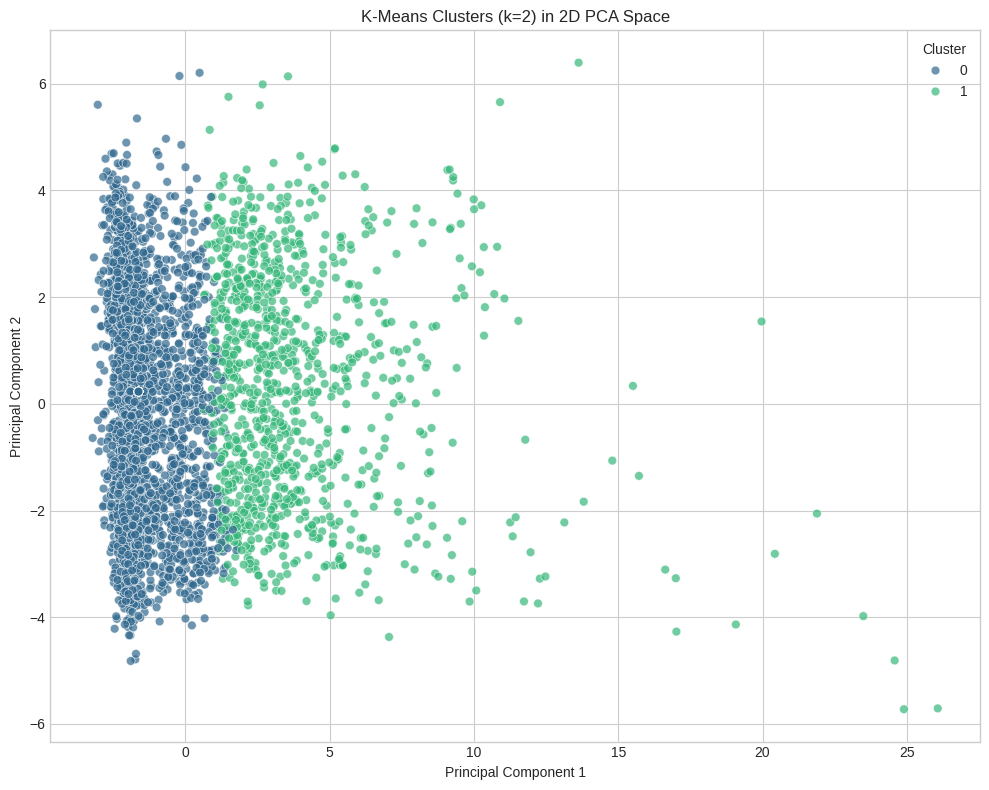


Flare rate (M/X) per K-Means Cluster:
kmeans_cluster
1    0.016167
0    0.000522
Name: flare_binary, dtype: float64


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reuse X_pca_full (all PCA components from the sampled PCA section)
# X_pca_full was computed as pca_full.fit_transform(X_scaled) on pca_source_df.


# Take the first 5 PCA components
X_pca_5 = X_pca_full[:, :5]

# Define the range of k values to try
k_values = range(2, 6)
inertia_values = []
silhouette_scores = []

print(f"Evaluating K-Means on the sampled PCA dataset with {len(X_pca_5):,} rows...")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca_5)

    inertia_values.append(kmeans.inertia_)

    silhouette_sample_size = min(len(X_pca_5), 10000)
    if len(X_pca_5) > silhouette_sample_size:
        sample_indices = np.random.default_rng(42).choice(len(X_pca_5), size=silhouette_sample_size, replace=False)
        sampled_X_pca_5 = X_pca_5[sample_indices]
        sampled_labels = kmeans.predict(sampled_X_pca_5)
        silhouette_scores.append(silhouette_score(sampled_X_pca_5, sampled_labels))
    else:
        silhouette_scores.append(silhouette_score(X_pca_5, kmeans.labels_))
    print(f"  k={k}: Inertia={inertia_values[-1]:.2f}, Silhouette Score={silhouette_scores[-1]:.3f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method for Optimal k (Inertia)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.tight_layout()
plt.show()

optimal_k_inertia = "Observe the elbow point where the decrease in inertia starts to slow down significantly."
optimal_k_silhouette = k_values[np.argmax(silhouette_scores)] if silhouette_scores else "N/A"

print("\nOptimal k based on Elbow Method (visual inspection):", optimal_k_inertia)
print(f"Optimal k based on Silhouette Score (highest value): {optimal_k_silhouette}")

optimal_k = optimal_k_silhouette
print(f"\nProceeding with optimal k = {optimal_k} for visualization.")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
optimal_clusters = kmeans_optimal.fit_predict(X_pca_5)

kmeans_plot_df = pd.DataFrame({
    "PC1": X_pca_full[:, 0],
    "PC2": X_pca_full[:, 1],
    "Cluster": optimal_clusters
})

k_means_sample_size = 4000
plot_sample_kmeans = kmeans_plot_df.sample(n=min(len(kmeans_plot_df), k_means_sample_size), random_state=42)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_sample_kmeans,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="viridis",
    alpha=0.7,
    s=40
)
plt.title(f"K-Means Clusters (k={optimal_k}) in 2D PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

cluster_flare_rate = (
    pd.DataFrame({
        "kmeans_cluster": optimal_clusters,
        "flare_binary": pca_source_df["flare_binary"].to_numpy(),
    })
    .groupby("kmeans_cluster")["flare_binary"]
    .mean()
    .sort_values(ascending=False)
 )
print("\nFlare rate (M/X) per K-Means Cluster:")
print(cluster_flare_rate)

### Hierarchical Clustering

57.	Apply Agglomerative Clustering with ward linkage on a sample of 500 observations.
58.	Plot a dendrogram using scipy.cluster.hierarchy.dendrogram. Where would you cut it?
59.	Compare cluster assignments from K-Means and Agglomerative Clustering using adjusted_rand_score. How similar are they?


Applying Agglomerative Clustering on a sample of 500 observations...


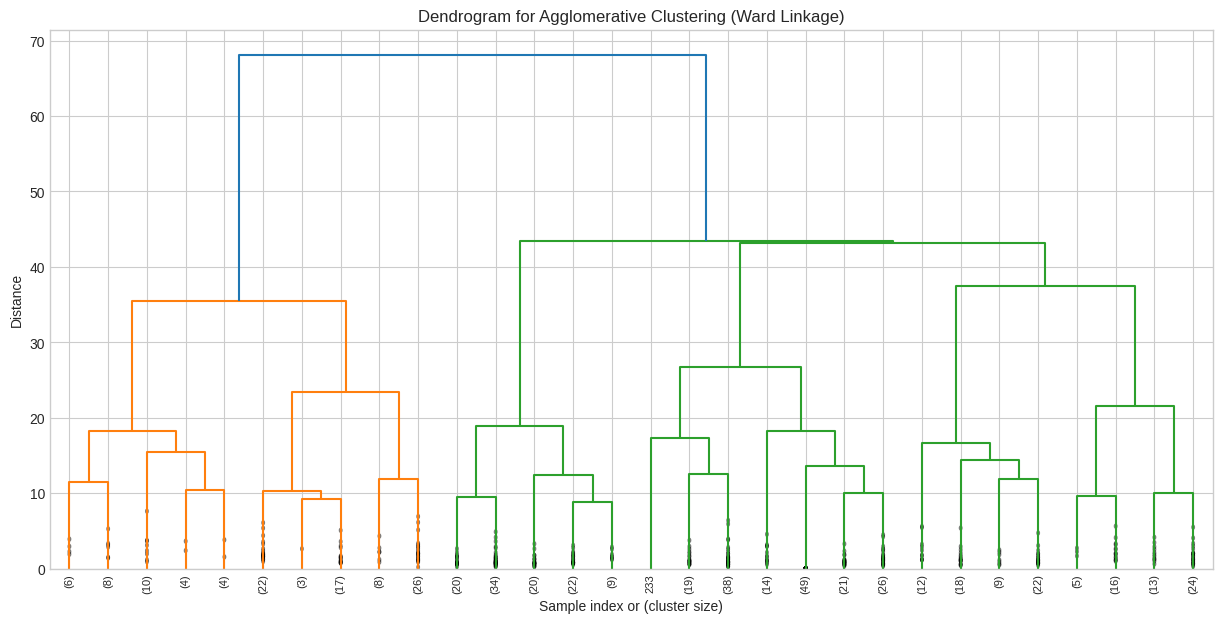


--- Interpreting the Dendrogram ---
To determine where to cut the dendrogram, look for the largest vertical distance that does not intersect any horizontal lines. Cutting the dendrogram at such a point indicates a natural number of clusters. For example, if you visually determine 3 major clusters, you would cut the dendrogram horizontally at a height that yields 3 vertical lines below it.
Agglomerative Clustering applied with k = 2 clusters.
Agglomerative Cluster counts:
0    392
1    108
Name: count, dtype: int64

K-Means Clustering applied to the same sample with k = 2 clusters.
K-Means Cluster counts:
0    351
1    149
Name: count, dtype: int64

Adjusted Rand Score between K-Means and Agglomerative Clustering: 0.654

--- Interpretation of Adjusted Rand Score ---
The Adjusted Rand Score (ARS) measures the similarity of the two assignments, ignoring permutations and with chance correction. A score close to 1.0 indicates very similar clusterings, while a score near 0.0 or negative ind

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Task 1: Apply Agglomerative Clustering with ward linkage on a sample ---

# Reuse X_pca_5 from the previous K-Means section
# X_pca_5 contains the first 5 PCA components of the standardized SHARP features.

sample_size_hc = 500

# To ensure comparability and manage computation for dendrogram
# We need to sample from X_pca_5 AND keep track of the original indices
np.random.seed(42)
random_indices = np.random.choice(X_pca_5.shape[0], size=sample_size_hc, replace=False)
X_pca_5_sample = X_pca_5[random_indices]

print(f"Applying Agglomerative Clustering on a sample of {sample_size_hc} observations...")

# Generate the linkage matrix for dendrogram
linked_matrix = linkage(X_pca_5_sample, method='ward')

# --- Task 2: Plot a dendrogram and identify where to cut it ---
plt.figure(figsize=(15, 7))
dendrogram(
    linked_matrix,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show last 30 merged clusters
    leaf_rotation=90.,      # rotates the x axis labels
    leaf_font_size=8.,      # font size for the x axis labels
    show_contracted=True,   # shows a line between merged clusters
)
plt.title('Dendrogram for Agglomerative Clustering (Ward Linkage)')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.show()

print("\n--- Interpreting the Dendrogram ---")
print("To determine where to cut the dendrogram, look for the largest vertical distance that does not intersect any horizontal lines. Cutting the dendrogram at such a point indicates a natural number of clusters. For example, if you visually determine 3 major clusters, you would cut the dendrogram horizontally at a height that yields 3 vertical lines below it.")

# For comparison with K-Means, we'll use the optimal_k identified previously.
# Assuming optimal_k is available from the previous cell's execution.
# If not, a default value like 3 or 4 could be chosen after inspecting the dendrogram.
if 'optimal_k' not in globals():
    optimal_k = 3 # Default if optimal_k from K-Means cell is not available
    print(f"(Note: optimal_k from K-Means not found, defaulting to {optimal_k})")

# Apply Agglomerative Clustering with the chosen number of clusters for comparison
agglom_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agglom_labels = agglom_clustering.fit_predict(X_pca_5_sample)

print(f"Agglomerative Clustering applied with k = {optimal_k} clusters.")
print("Agglomerative Cluster counts:")
print(pd.Series(agglom_labels).value_counts().sort_index())

# --- Task 3: Compare cluster assignments from K-Means and Agglomerative Clustering ---

# Re-run K-Means on the *same sample* to get comparable labels
kmeans_sample = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_sample_labels = kmeans_sample.fit_predict(X_pca_5_sample)

print(f"\nK-Means Clustering applied to the same sample with k = {optimal_k} clusters.")
print("K-Means Cluster counts:")
print(pd.Series(kmeans_sample_labels).value_counts().sort_index())

# Calculate Adjusted Rand Score
ars = adjusted_rand_score(kmeans_sample_labels, agglom_labels)

print(f"\nAdjusted Rand Score between K-Means and Agglomerative Clustering: {ars:.3f}")

print("\n--- Interpretation of Adjusted Rand Score ---")
print("The Adjusted Rand Score (ARS) measures the similarity of the two assignments, ignoring permutations and with chance correction. A score close to 1.0 indicates very similar clusterings, while a score near 0.0 or negative indicates random assignment or disagreement. The computed ARS suggests how consistent K-Means and Agglomerative Clustering (with Ward linkage) are in grouping the data points from the sample.")


### HDBSCAN

57.	Apply HDBSCAN on a sample of the first 5 PCA components.
58.	Inspect the discovered clusters and noise points in PCA space.
59.	Compare HDBSCAN assignments with K-Means using adjusted_rand_score on the non-noise subset.

Applying HDBSCAN on a sample of 5,000 PCA observations...
HDBSCAN label counts (-1 indicates noise):
-1    2233
 0     219
 1     197
 2    2321
 3      30
Name: count, dtype: int64
Noise fraction: 0.447


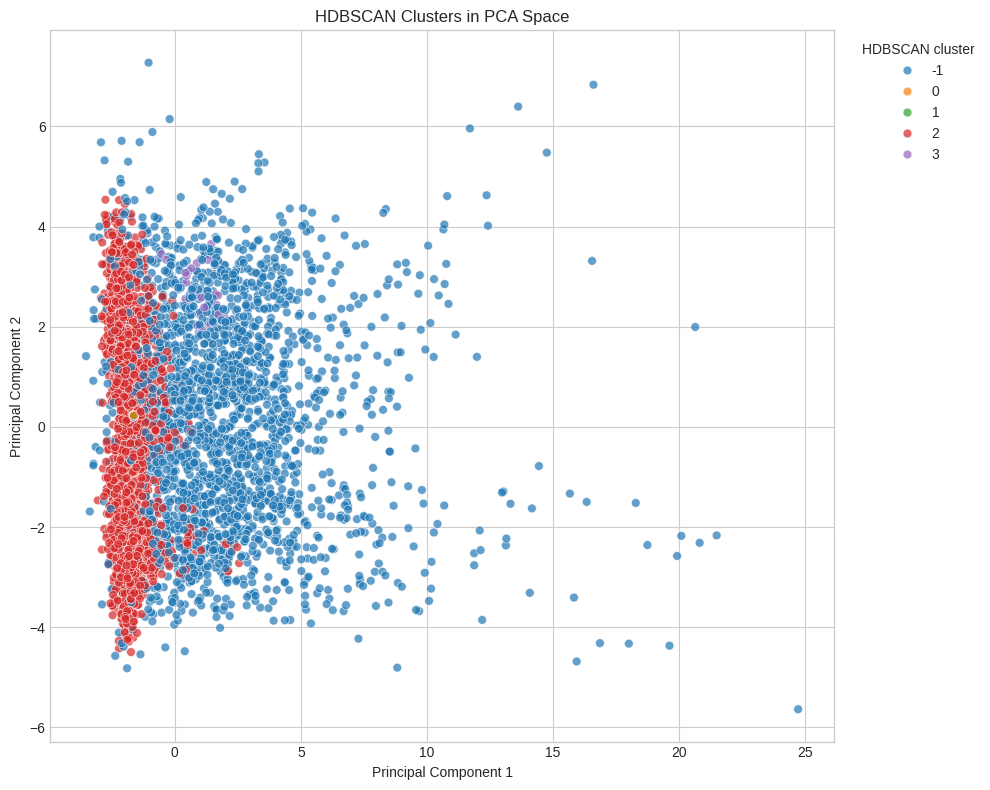


Interpretation:
HDBSCAN identifies dense regions automatically and labels low-density points as noise (-1), so it can reveal structure that fixed-k clustering may miss.

K-Means clustering applied to the HDBSCAN non-noise subset with k = 2.
K-Means cluster counts:
0    1636
1    1131
Name: count, dtype: int64

Adjusted Rand Score between K-Means and HDBSCAN: -0.024

Interpretation of Adjusted Rand Score:
A score close to 1.0 means the two methods group the non-noise points similarly, while a score near 0.0 indicates they capture different structure in the sampled PCA space.


In [ ]:
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from sklearn.cluster import HDBSCAN
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hdbscan"])
    from hdbscan import HDBSCAN

# --- Task 1: Apply HDBSCAN on a sample of the first 5 PCA components ---

# Reuse X_pca_5 from the previous K-Means section.
hdbscan_sample_size = min(X_pca_5.shape[0], 5000)
sample_rng = np.random.default_rng(42)
sample_indices = sample_rng.choice(X_pca_5.shape[0], size=hdbscan_sample_size, replace=False)
X_pca_5_sample = X_pca_5[sample_indices]

print(f"Applying HDBSCAN on a sample of {hdbscan_sample_size:,} PCA observations...")

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    cluster_selection_method="eom"
 )
hdbscan_labels = hdbscan_model.fit_predict(X_pca_5_sample)

cluster_counts = pd.Series(hdbscan_labels).value_counts().sort_index()
noise_fraction = (hdbscan_labels == -1).mean()

print("HDBSCAN label counts (-1 indicates noise):")
print(cluster_counts)
print(f"Noise fraction: {noise_fraction:.3f}")

# --- Task 2: Visualize HDBSCAN clusters and noise in PCA space ---
hdbscan_plot_df = pd.DataFrame({
    "PC1": X_pca_5_sample[:, 0],
    "PC2": X_pca_5_sample[:, 1],
    "HDBSCAN_cluster": hdbscan_labels,
})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=hdbscan_plot_df,
    x="PC1",
    y="PC2",
    hue="HDBSCAN_cluster",
    palette="tab10",
    alpha=0.7,
    s=40,
 )
plt.title("HDBSCAN Clusters in PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="HDBSCAN cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("HDBSCAN identifies dense regions automatically and labels low-density points as noise (-1), so it can reveal structure that fixed-k clustering may miss.")

# --- Task 3: Compare HDBSCAN with K-Means on the non-noise subset ---
if 'optimal_k' not in globals():
    optimal_k = 3
    print(f"(Note: optimal_k from K-Means not found, defaulting to {optimal_k})")

non_noise_mask = hdbscan_labels != -1
if non_noise_mask.sum() < 2 or pd.Series(hdbscan_labels[non_noise_mask]).nunique() < 2:
    print("\nHDBSCAN did not produce enough non-noise clusters for a meaningful ARS comparison.")
else:
    X_non_noise = X_pca_5_sample[non_noise_mask]
    hdbscan_non_noise = hdbscan_labels[non_noise_mask]

    kmeans_sample = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    kmeans_sample_labels = kmeans_sample.fit_predict(X_non_noise)

    print(f"\nK-Means clustering applied to the HDBSCAN non-noise subset with k = {optimal_k}.")
    print("K-Means cluster counts:")
    print(pd.Series(kmeans_sample_labels).value_counts().sort_index())

    ars = adjusted_rand_score(kmeans_sample_labels, hdbscan_non_noise)
    print(f"\nAdjusted Rand Score between K-Means and HDBSCAN: {ars:.3f}")

    print("\nInterpretation of Adjusted Rand Score:")
    print("A score close to 1.0 means the two methods group the non-noise points similarly, while a score near 0.0 indicates they capture different structure in the sampled PCA space.")

## Solar Flare Nowcasting
Predict the flare class from SHARP parameters observed at the same timestamp (no temporal lag).

35.	Split data into train/test sets (80/20) using train_test_split with stratify=y.
36.	Train a RandomForestClassifier(n_estimators=100).
37.	Evaluate on the test set: print the classification report (precision, recall, F1 per class) and plot the confusion matrix as a heatmap.
38.	Plot feature importances from the Random Forest. Do they match your correlation findings?
39.	Apply SMOTE (imblearn.over_sampling.SMOTE) to handle class imbalance. Does it improve recall for rare classes (M, X)?

For solar flare forecasting with SHARP data, we want to keep only the SHARP magnetic parameters (input features)

In [ ]:
sharp_features = [
    'TOTUSJH',
    'TOTBSQ',
    'TOTPOT',
    'TOTUSJZ',
    'ABSNJZH',
    'SAVNCPP',
    'USFLUX',
    'TOTFZ',
    'MEANPOT',
    'R_VALUE',
    'AREA_ACR',
    'SHRGT45',
    'MEANGAM',
    'MEANGBT',
    'MEANGBZ',
    'MEANGBH',
    'MEANJZH',
    'TOTFY',
    'MEANJZD',
    'MEANALP',
    'TOTFX',
    'EPSZ',
    'MEANSHR',
    'MEANJGT',
    'MEANAPT',
    'MEANEXT'
]

metadata_cols = [
    'SHARPnum',
    'Timestamp'
]

target_col = 'flare_class'

drop_cols = [
    'Unnamed: 0',

    # Future flare labels (data leakage!)
    'CFLARE_LOC',
    'CFLARE_LABEL_LOC',
    'MFLARE_LOC',
    'MFLARE_LABEL_LOC',
    'XFLARE_LOC',
    'XFLARE_LABEL_LOC',

    # Target-related quantities
    'XR_MAX',
    'XR_QUAL',
    'flare_class',

    # Flags
    'IS_TMFI',

    # Identifiers
    'SHARPnum'
]

In [ ]:
available_features = [
    col for col in sharp_features
    if col in df_preprocessed.columns
]

print(f"Found {len(available_features)} SHARP features")
print(available_features)

In [ ]:
y = df_preprocessed["flare_class"].copy()

print(y.value_counts())

In [ ]:
# Define ordered flare classes
flare_mapping = {
    'No Flare': 0,
    'B': 1,
    'C': 2,
    'M': 3,
    'X': 4
}

# Convert labels
y_encoded = y.map(flare_mapping)

print(flare_mapping)
print(y_encoded.head())

In [ ]:
y.value_counts().plot(
    kind="bar"
)

plt.title("Flare Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")
plt.show()

print(y.value_counts())

In [ ]:
# 35
from sklearn.model_selection import train_test_split

X = df_preprocessed[available_features]
y = df_preprocessed["flare_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True))

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# training can take much time and might not be possible
# in collab
# You could try reducing the amoung of data
# and play with lighter paraneter settings for RF

rf_fast = RandomForestClassifier(
    n_estimators=20,
    max_depth=8,
    min_samples_leaf=10,
    max_samples=0.5,        # each tree sees only 50% of training data
    random_state=42,
    n_jobs=-1
)

rf_fast.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=rf.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf.classes_,
    yticklabels=rf.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,8))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

print(importances.head(15))

In [ ]:
# 30 SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

In [ ]:
print(classification_report(y_test, y_pred_smote))

In [ ]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote,
    labels=rf_smote.classes_
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=rf_smote.classes_,
    yticklabels=rf_smote.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (SMOTE)")
plt.show()

## Solar Flare Forecasting

### 24h Forecast
Predict whether an active region will produce a flare in the next 24 hours, using observations at time t to label events at time t + 24h

40.	Construct the forecast target: for each observation at time t, assign label 1 if any M/X flare occurred in the following 24 hours, else 0.
41.	Use a temporal train/test split — do NOT shuffle the data. Use observations before a cutoff date for training. Why must the split be temporal?
42.	Train a GradientBoostingClassifier or XGBClassifier. Evaluate with: TSS (True Skill Statistic), HSS (Heidke Skill Score), and ROC-AUC.
43.	Plot the ROC curve and Precision-Recall curve. Which is more informative for an imbalanced dataset, and why?





In [ ]:
# Metric formulae for solar flare forecasting
# TSS = TP/(TP+FN) - FP/(FP+TN)   (ranges -1 to +1)
# HSS = 2(TP*TN - FN*FP) / [(TP+FN)(FN+TN) + (TP+FP)(FP+TN)]
# POD = TP / (TP + FN)              (Probability of Detection)
# FAR = FP / (FP + TN)              (False Alarm Rate)

In [ ]:
# Some helpful code to get you started...

# This assumes:

# df.index is Timestamp
# df["SHARPnum"] identifies the active region
# df["flare_class"] contains "No flare", "C", "M", "X"

import pandas as pd
import numpy as np

df_for = df_preprocessed.copy()
df_for = df_preprocessed.sort_index()

# Binary flare flag at each timestamp
df_for["is_MX_now"] = df_for["flare_class"].isin(["M", "X"]).astype(int)

# Create 24h forecast target per active region
df_for["target_24h_MX"] = 0

for sharpnum, group in df_for.groupby("SHARPnum"):
    group = group.sort_index()

    times = group.index
    labels = group["is_MX_now"].values

    target = []

    for t in times:
        future_window = group.loc[
            (group.index > t) &
            (group.index <= t + pd.Timedelta(hours=24))
        ]

        target.append(int(future_window["is_MX_now"].any()))

    df_for.loc[group.index, "target_24h_MX"] = target

print(df_for["target_24h_MX"].value_counts())

## 48-Hour Forecast

44.	Repeat Exercise 40-43 with a 48-hour forecast horizon.
45.	Compare ROC-AUC and TSS scores between 24h and 48h forecasts. Which is harder to predict, and why?



Evaluation Hints:

* Compute and display F1 scores. Show the confusion matrix
* Merge classes into two groups: No-flare (B/C/None) vs. Significant flare (M/X).
* Compute: Accuracy, Precision, Recall, F1, TSS, HSS, FAR (False Alarm Rate), POD (Probability of Detection).

* (Bonus) Implement a simple persistence baseline: predict that the next window will have the same label as the current one. How does your model compare to this baseline?

# Conclusions

*   Which SHARP parameters were most important across all your models? Are these

*   What are the main challenges of solar flare forecasting compared to a standard classification problem
consistent with the solar physics literature?

*   Suggest improvements you would implement with more time

